# ADNI 기반 뇌 연령(BAG) 측정 및 취약 부위 3D 시각화

## 분석 목적

1. ADNI T1 MRI FreeSurfer 표형 지표로 정상 노화 기준의 뇌 연령을 예측합니다.
2. 예측 뇌 연령의 연령 편향을 보정한 뒤, 실제 연령과의 차이인 **Bias-Corrected BAG**를 계산합니다.
3. RID별 가장 이른 유효 T1 MRI 한 건만 사용하여 반복 촬영에 따른 데이터 누수를 막습니다.
4. Ridge 회귀의 독립 테스트와 중첩 교차검증 성능을 비교하여 과적합 위험을 점검합니다.
5. CN, MCI, AD 집단의 BAG 및 피질 취약 부위를 통계적으로 비교하고 3D 뇌 표면에 표시합니다.

> 연구용 분석입니다. BAG와 3D 지도는 개인의 진단 또는 임상 의사결정을 대체하지 않습니다.

## 실행 순서

이 노트북은 프로젝트 내부 `01_원본데이터/ADNI_data.zip`만 참조합니다.
위에서 아래로 **Run All**을 실행하면 필요한 CSV를 자동 추출하고, 각 장의 데이터와 결과를 해당 한글 폴더에 저장합니다.

## 발표용 추천 흐름

발표에서는 1) 연구 목적, 2) 데이터 선별과 Index MRI, 3) Ridge 뇌 연령 모델, 4) 나이 편향 보정과 BAG, 5) 독립 테스트와 과적합 점검, 6) 집단 BAG 결과, 7) 취약 부위와 3D 지도, 8) RID별 개인 지도 순서로 설명하면 자연스럽습니다.

실행 결과 중 핵심 수치는 마지막 11장에서 자동 요약되며, 개인 예시는 10.2의 RID를 변경하거나 10.3의 검색·비교 도구로 시연합니다.

In [1]:
# 0. 분석 환경, 프로젝트 내부 경로, 난수 시드 설정
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import hashlib
import json
import os
import platform
import shutil
import warnings
from io import BytesIO
from zipfile import ZipFile

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import statsmodels.formula.api as smf

from IPython.display import Markdown, display
from matplotlib import font_manager
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_SEED = 20260822
rng = np.random.default_rng(RANDOM_SEED)
NOTEBOOK_NAME = "ADNI_뇌연령_BAG_3D_분석.ipynb"


def find_project_dir() -> Path:
    '''현재 작업 폴더의 상위 경로에서 프로젝트 루트를 찾습니다.'''
    override = os.environ.get("ADNI_BAG_PROJECT_DIR")
    if override:
        candidate = Path(override).expanduser().resolve()
        if (candidate / NOTEBOOK_NAME).is_file():
            return candidate
        raise RuntimeError(f"ADNI_BAG_PROJECT_DIR가 프로젝트 폴더가 아닙니다: {candidate}")

    working_dir = Path.cwd().resolve()
    for candidate in (working_dir, *working_dir.parents):
        if (candidate / NOTEBOOK_NAME).is_file():
            return candidate
    raise RuntimeError(
        "프로젝트 폴더를 찾지 못했습니다. "
        "ADNI_뇌연령_BAG_3D_최종프로젝트 폴더에서 노트북을 여세요."
    )


PROJECT_DIR = find_project_dir()
RAW_DIR = PROJECT_DIR / "01_원본데이터"
PREPROCESS_DIR = PROJECT_DIR / "02_전처리결과"
MODEL_DIR = PROJECT_DIR / "03_모델학습_검증결과"
BAG_DIR = PROJECT_DIR / "04_BAG_집단분석결과"
RENDER_DIR = PROJECT_DIR / "05_취약부위_3D렌더링"
PERSONAL_RENDER_DIR = PROJECT_DIR / "06_RID별_개인_3D렌더링"
PERSONAL_OUTPUT_DIR = PERSONAL_RENDER_DIR / "현재실행_생성결과"
HELP_DIR = PROJECT_DIR / "07_실행환경_도움말"
ASSET_DIR = PROJECT_DIR / "assets"
for directory in [RAW_DIR, PREPROCESS_DIR, MODEL_DIR, BAG_DIR, RENDER_DIR, PERSONAL_RENDER_DIR, HELP_DIR, ASSET_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
PERSONAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

archive_file = RAW_DIR / "ADNI_data.zip"
if not archive_file.is_file():
    raise FileNotFoundError(f"프로젝트 내부 원본 압축파일을 찾지 못했습니다: {archive_file}")

sns.set_theme(style="whitegrid", context="notebook")
korean_font = Path(os.environ.get("WINDIR", "C:/Windows")) / "Fonts" / "NotoSansKR-Regular.ttf"
if korean_font.exists():
    font_manager.fontManager.addfont(str(korean_font))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(korean_font)).get_name()
else:
    plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("프로젝트 내부 상대 경로를 사용합니다.")
print(f"원본 압축파일: {archive_file.name}")
print(f"Python: {platform.python_version()} | scikit-learn: {sklearn.__version__}")
print(f"실행 시각: {datetime.now():%Y-%m-%d %H:%M:%S}")

프로젝트 내부 상대 경로를 사용합니다.
원본 압축파일: ADNI_data.zip
Python: 3.13.9 | scikit-learn: 1.8.0
실행 시각: 2026-08-24 12:08:50


## 1. 프로젝트 내부 원본 데이터 추출

ADNI 배포 제한을 지키기 위해 ZIP 전체를 외부에 풀지 않고, 분석에 필요한 T1 FreeSurfer·진단 이력·인구학 CSV만 프로젝트 내부에 추출합니다.

In [2]:
# 1. 원본 ZIP 안의 필요한 CSV만 내부 폴더로 추출합니다.
EXTRACT_DIR = RAW_DIR / "추출된필수CSV"
extraction_plan = {
    "ADSP_PHC.zip": ["ADSP_PHC_T1_FS_22Jan2026.csv"],
    "Assessments.zip": ["DXSUM_22Jan2026.csv", "CDR_22Jan2026.csv"],
    "Subject_Characteristics.zip": ["PTDEMOG_22Jan2026.csv"],
}


def extract_nested_csv(outer_archive: Path, nested_archive: str, filename: str) -> Path:
    destination = EXTRACT_DIR / Path(nested_archive).stem / filename
    if destination.is_file() and destination.stat().st_size > 0:
        return destination

    destination.parent.mkdir(parents=True, exist_ok=True)
    with ZipFile(outer_archive) as outer_zip:
        with ZipFile(BytesIO(outer_zip.read(nested_archive))) as inner_zip:
            with inner_zip.open(filename) as source, destination.open("wb") as target:
                shutil.copyfileobj(source, target, length=1024 * 1024)
    return destination


extracted_files = {}
for nested_archive, filenames in extraction_plan.items():
    for filename in filenames:
        extracted_files[filename] = extract_nested_csv(archive_file, nested_archive, filename)

T1_FILE = extracted_files["ADSP_PHC_T1_FS_22Jan2026.csv"]
DXSUM_FILE = extracted_files["DXSUM_22Jan2026.csv"]
CDR_FILE = extracted_files["CDR_22Jan2026.csv"]
PTDEMOG_FILE = extracted_files["PTDEMOG_22Jan2026.csv"]


def sha256sum(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


extraction_manifest = pd.DataFrame([
    {
        "원본ZIP": archive_file.name,
        "추출파일": path.name,
        "상대경로": str(path.relative_to(PROJECT_DIR)),
        "바이트": path.stat().st_size,
        "SHA256": sha256sum(path),
    }
    for path in extracted_files.values()
])
extraction_manifest.to_csv(PREPROCESS_DIR / "원본추출_파일목록.csv", index=False, encoding="utf-8-sig")
display(extraction_manifest)

,원본ZIP,추출파일,상대경로,바이트,SHA256
0,ADNI_data.zip,ADSP_PHC_T1_FS_22Jan2026.csv,01_원본데이터\추출된필수CSV\ADSP_PHC\ADSP_PHC_T1_FS_22Ja...,39163174,d74bd62ad96ec6dfaa751137746cc94d00970053a63f16...
1,ADNI_data.zip,DXSUM_22Jan2026.csv,01_원본데이터\추출된필수CSV\Assessments\DXSUM_22Jan2026.csv,3440780,77bb910a744095db68500fe3e6aff629be2a3e18251d90...
2,ADNI_data.zip,CDR_22Jan2026.csv,01_원본데이터\추출된필수CSV\Assessments\CDR_22Jan2026.csv,2605705,838d39df1ad0988eb760390d5ff648398e98f0fe689254...
3,ADNI_data.zip,PTDEMOG_22Jan2026.csv,01_원본데이터\추출된필수CSV\Subject_Characteristics\PTDE...,2300589,34652fbd561de172516b8e3e1da6941cfc4b6e2c1b021f...


## 2. 입력 데이터 확인과 변수 정의

`PHC_Education`은 교육연수(년)입니다. T1 FreeSurfer 파일에 이미 포함되어 있어, 같은 시점의 MRI 행과 별도 병합하지 않고 사용합니다. `PTDEMOG` 파일은 인구학 정보의 보조 확인용입니다.

In [3]:
# 2. 원자료를 읽고 모델 입력 열을 명시적으로 정의합니다.
raw_t1 = pd.read_csv(T1_FILE, low_memory=False)
dx_history = pd.read_csv(DXSUM_FILE, low_memory=False)
cdr_history = pd.read_csv(CDR_FILE, low_memory=False)
demographics = pd.read_csv(PTDEMOG_FILE, low_memory=False)

ICV_COLUMN = "EstimatedTotalIntraCranialVol_combat"
combat_columns = [column for column in raw_t1.columns if column.endswith("_combat")]
if ICV_COLUMN not in combat_columns:
    raise KeyError(f"필수 ICV 열이 없습니다: {ICV_COLUMN}")

ROI_COLUMNS = [column for column in combat_columns if column != ICV_COLUMN]
FEATURE_COLUMNS = [*ROI_COLUMNS, "PHC_Sex", "PHC_Education", ICV_COLUMN]
REQUIRED_BASE_COLUMNS = [
    "RID", "PHC_SCANDATE", "PHC_Age_T1", "PHC_Sex", "PHC_Education",
    "PHC_Diagnosis", ICV_COLUMN,
]
missing_columns = [column for column in [*REQUIRED_BASE_COLUMNS, *FEATURE_COLUMNS] if column not in raw_t1.columns]
if missing_columns:
    raise KeyError(f"필수 열이 없습니다: {missing_columns}")

source_summary = pd.DataFrame([
    {"파일": T1_FILE.name, "행": len(raw_t1), "RID 수": raw_t1["RID"].nunique(), "설명": "T1 FreeSurfer ComBat 지표"},
    {"파일": DXSUM_FILE.name, "행": len(dx_history), "RID 수": dx_history["RID"].nunique(), "설명": "진단 방문 이력"},
    {"파일": PTDEMOG_FILE.name, "행": len(demographics), "RID 수": demographics["RID"].nunique(), "설명": "인구학 보조 확인 자료"},
])
source_summary.to_csv(PREPROCESS_DIR / "입력데이터_요약.csv", index=False, encoding="utf-8-sig")

variable_dictionary = pd.DataFrame([
    {"분류": "예측 목표", "열": "PHC_Age_T1", "설명": "T1 MRI 촬영 시 실제 연령"},
    {"분류": "모델 입력", "열": "*_combat", "설명": f"ComBat 조화 FreeSurfer ROI {len(ROI_COLUMNS)}개"},
    {"분류": "모델 입력", "열": "PHC_Sex", "설명": "ADNI 성별 코드"},
    {"분류": "모델 입력", "열": "PHC_Education", "설명": "교육연수(년)"},
    {"분류": "모델 입력", "열": ICV_COLUMN, "설명": "추정 두개강내총용적(eTIV/ICV)"},
    {"분류": "분석용", "열": "PHC_Diagnosis", "설명": "촬영 시점 진단: 1=CN, 2=MCI, 3=AD"},
    {"분류": "식별·정렬용", "열": "RID, PHC_SCANDATE", "설명": "개인별 최초 유효 T1 선택에만 사용; 모델 입력 제외"},
])
variable_dictionary.to_csv(PREPROCESS_DIR / "변수사전.csv", index=False, encoding="utf-8-sig")
display(source_summary)
print(f"ROI {len(ROI_COLUMNS)}개 + 성별 + 교육연수 + ICV = 모델 입력 {len(FEATURE_COLUMNS)}개")

,파일,행,RID 수,설명
0,ADSP_PHC_T1_FS_22Jan2026.csv,10260,2504,T1 FreeSurfer ComBat 지표
1,DXSUM_22Jan2026.csv,15992,3788,진단 방문 이력
2,PTDEMOG_22Jan2026.csv,6222,4946,인구학 보조 확인 자료


ROI 191개 + 성별 + 교육연수 + ICV = 모델 입력 194개


## 3. 전처리: 결측값, 유효성, Index MRI

한 사람의 반복 MRI가 훈련·검증·테스트에 동시에 들어가면 성능이 부풀려질 수 있습니다. 이를 막기 위해 모든 필수 변수가 유효한 검사 중 RID별 가장 이른 T1 MRI만 남깁니다.

In [4]:
# 3. 수치 변환, 유효성 검사, RID별 index MRI 선택
DIAGNOSIS_LABELS = {1: "CN", 2: "MCI", 3: "AD"}
SEX_LABELS = {1: "Male", 2: "Female"}

work = raw_t1.copy()
work["_source_row"] = np.arange(1, len(work) + 1)
work["_scan_date"] = pd.to_datetime(work["PHC_SCANDATE"], errors="coerce")
work["PHC_Age_T1"] = pd.to_numeric(work["PHC_Age_T1"], errors="coerce")
work["PHC_Sex"] = pd.to_numeric(work["PHC_Sex"], errors="coerce")
work["PHC_Education"] = pd.to_numeric(work["PHC_Education"], errors="coerce")
work["PHC_Diagnosis"] = pd.to_numeric(work["PHC_Diagnosis"], errors="coerce")
work[FEATURE_COLUMNS] = work[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
work["diagnosis"] = work["PHC_Diagnosis"].map(DIAGNOSIS_LABELS)
work["sex_label"] = work["PHC_Sex"].map(SEX_LABELS)

# 사전 정의된 유효 범위 밖 값은 결측으로 바꾼 뒤 complete-case 기준에 반영합니다.
work.loc[~work["PHC_Age_T1"].between(40, 100), "PHC_Age_T1"] = np.nan
work.loc[~work["PHC_Sex"].isin([1, 2]), "PHC_Sex"] = np.nan
work.loc[~work["PHC_Education"].between(0, 30), "PHC_Education"] = np.nan
work.loc[work[ICV_COLUMN] <= 0, ICV_COLUMN] = np.nan
work[FEATURE_COLUMNS] = work[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)

required_columns = ["RID", "_scan_date", "PHC_Age_T1", "PHC_Sex", "PHC_Education", "diagnosis", *FEATURE_COLUMNS]
complete_mask = work[required_columns].notna().all(axis=1)
eligible_scans = work.loc[complete_mask].copy()
eligible_scans = eligible_scans.sort_values(["RID", "_scan_date", "_source_row"])
analysis_df = eligible_scans.groupby("RID", as_index=False, sort=False).first().copy()
analysis_df["analysis_group"] = analysis_df["diagnosis"]


# 개인별 검색 화면에서 보여 줄 임상 정보입니다. 이 값들은 Ridge 뇌연령 모델의 입력에는 포함하지 않습니다.
SEX_LABELS_KO = {1: "남성", 2: "여성"}
CDR_GLOBAL_LABELS = {
    0.0: "정상", 0.5: "매우 경도", 1.0: "경도", 2.0: "중등도", 3.0: "중증",
}
PERSONAL_CLINICAL_COLUMNS = [
    "sex_label_ko", "cdr_assessment_date", "cdr_days_from_mri", "cdr_global", "cdr_global_label",
    "cdr_sb", "longitudinal_first_diagnosis", "longitudinal_latest_diagnosis",
    "first_ad_diagnosis_date", "years_from_index_to_first_ad", "ad_progression_status",
]

# DXSUM은 MRI 시점 진단과 별개로, 추적 진단이 어떻게 변화했는지 보여 주기 위한 이력 자료입니다.
dx_longitudinal = dx_history[["RID", "EXAMDATE", "DIAGNOSIS"]].copy()
dx_longitudinal["diagnosis_date"] = pd.to_datetime(dx_longitudinal["EXAMDATE"], errors="coerce")
dx_longitudinal["diagnosis_numeric"] = pd.to_numeric(dx_longitudinal["DIAGNOSIS"], errors="coerce")
dx_longitudinal = dx_longitudinal.loc[
    dx_longitudinal["diagnosis_date"].notna() & dx_longitudinal["diagnosis_numeric"].isin(DIAGNOSIS_LABELS)
].sort_values(["RID", "diagnosis_date"])
first_dx = dx_longitudinal.groupby("RID", as_index=False).first()[["RID", "diagnosis_numeric"]]
first_dx = first_dx.rename(columns={"diagnosis_numeric": "first_diagnosis_numeric"})
latest_dx = dx_longitudinal.groupby("RID", as_index=False).last()[["RID", "diagnosis_numeric"]]
latest_dx = latest_dx.rename(columns={"diagnosis_numeric": "latest_diagnosis_numeric"})
first_ad = (
    dx_longitudinal.loc[dx_longitudinal["diagnosis_numeric"].eq(3)]
    .groupby("RID", as_index=False)["diagnosis_date"].min()
    .rename(columns={"diagnosis_date": "first_ad_diagnosis_date"})
)
longitudinal_summary = first_dx.merge(latest_dx, on="RID", how="outer").merge(first_ad, on="RID", how="left")
longitudinal_summary["longitudinal_first_diagnosis"] = longitudinal_summary["first_diagnosis_numeric"].map(DIAGNOSIS_LABELS)
longitudinal_summary["longitudinal_latest_diagnosis"] = longitudinal_summary["latest_diagnosis_numeric"].map(DIAGNOSIS_LABELS)
longitudinal_summary = longitudinal_summary.drop(columns=["first_diagnosis_numeric", "latest_diagnosis_numeric"])

# CDR은 MRI 날짜와 가장 가까운 평가를 최대 365일 범위에서 연결합니다.
cdr_longitudinal = cdr_history[["RID", "VISDATE", "CDGLOBAL", "CDRSB"]].copy()
cdr_longitudinal["cdr_assessment_date"] = pd.to_datetime(cdr_longitudinal["VISDATE"], errors="coerce")
cdr_longitudinal["cdr_global"] = pd.to_numeric(cdr_longitudinal["CDGLOBAL"], errors="coerce")
cdr_longitudinal["cdr_sb"] = pd.to_numeric(cdr_longitudinal["CDRSB"], errors="coerce")
cdr_longitudinal.loc[~cdr_longitudinal["cdr_global"].isin(CDR_GLOBAL_LABELS), "cdr_global"] = np.nan
cdr_longitudinal.loc[~cdr_longitudinal["cdr_sb"].between(0, 18), "cdr_sb"] = np.nan
cdr_longitudinal = cdr_longitudinal.loc[
    cdr_longitudinal["cdr_assessment_date"].notna() &
    (cdr_longitudinal["cdr_global"].notna() | cdr_longitudinal["cdr_sb"].notna())
].copy()
index_dates = analysis_df[["RID", "_scan_date"]].copy()
cdr_candidates = index_dates.merge(cdr_longitudinal, on="RID", how="left")
cdr_candidates["cdr_days_from_mri"] = (
    cdr_candidates["cdr_assessment_date"] - cdr_candidates["_scan_date"]
).abs().dt.days
cdr_nearest = (
    cdr_candidates.loc[cdr_candidates["cdr_days_from_mri"].le(365)]
    .sort_values(["RID", "cdr_days_from_mri", "cdr_assessment_date"])
    .groupby("RID", as_index=False).first()[
        ["RID", "cdr_assessment_date", "cdr_days_from_mri", "cdr_global", "cdr_sb"]
    ]
)

analysis_df = analysis_df.merge(longitudinal_summary, on="RID", how="left")
analysis_df = analysis_df.merge(cdr_nearest, on="RID", how="left")
analysis_df["sex_label_ko"] = analysis_df["PHC_Sex"].map(SEX_LABELS_KO)
analysis_df["cdr_global_label"] = analysis_df["cdr_global"].map(CDR_GLOBAL_LABELS).fillna("연결된 CDR 평가 없음")
analysis_df["years_from_index_to_first_ad"] = (
    analysis_df["first_ad_diagnosis_date"] - analysis_df["_scan_date"]
).dt.days / 365.25

def ad_progression_text(row):
    if row["analysis_group"] == "AD":
        return "Index MRI 시점 AD"
    if pd.notna(row["first_ad_diagnosis_date"]) and row["years_from_index_to_first_ad"] >= 0:
        return f"Index MRI 이후 AD 진단 기록 ({row['years_from_index_to_first_ad']:.1f}년 후)"
    if pd.notna(row["first_ad_diagnosis_date"]):
        return "MRI 전후 진단 이력의 AD 기록 확인 필요"
    return "AD 진단 기록 없음"

analysis_df["ad_progression_status"] = analysis_df.apply(ad_progression_text, axis=1)
clinical_match_audit = pd.DataFrame([
    {"항목": "MRI 365일 이내 CDR 연결", "RID 수": int(analysis_df["cdr_assessment_date"].notna().sum()), "설명": "CDR Global 또는 CDR-SB가 있는 가장 가까운 평가"},
    {"항목": "CDR 미연결", "RID 수": int(analysis_df["cdr_assessment_date"].isna().sum()), "설명": "개인 결과에는 미측정/연결불가로 표시"},
    {"항목": "추적 AD 진단 기록", "RID 수": int(analysis_df["first_ad_diagnosis_date"].notna().sum()), "설명": "DXSUM 진단 이력 기준"},
])
clinical_match_audit.to_csv(PREPROCESS_DIR / "개인검색_임상정보_연결감사표.csv", index=False, encoding="utf-8-sig")

if not analysis_df["RID"].is_unique:
    raise RuntimeError("Index MRI 코호트에 RID 중복이 남아 있습니다.")
if not np.isfinite(analysis_df[FEATURE_COLUMNS].to_numpy(dtype=float)).all():
    raise RuntimeError("최종 코호트에 비유한 입력값이 남아 있습니다.")

cohort_flow = pd.DataFrame([
    {"단계": "원본 T1 MRI 검사", "검사 수": len(work), "RID 수": work["RID"].nunique()},
    {"단계": "필수 변수 유효 검사 통과", "검사 수": len(eligible_scans), "RID 수": eligible_scans["RID"].nunique()},
    {"단계": "RID별 최초 유효 T1 (Index MRI)", "검사 수": len(analysis_df), "RID 수": analysis_df["RID"].nunique()},
])
diagnosis_counts = analysis_df.groupby("analysis_group", observed=True).size().rename("인원").reset_index()

roi_values = analysis_df[ROI_COLUMNS]
roi_median = roi_values.median(axis=0)
roi_mad = roi_values.sub(roi_median, axis=1).abs().median(axis=0).replace(0, np.nan)
robust_z = roi_values.sub(roi_median, axis=1).div(1.4826 * roi_mad, axis=1)
extreme_count = robust_z.abs().gt(6).sum(axis=1)
audit = pd.DataFrame([
    {"점검 항목": "필수 변수 결측", "결과": f"제외 검사 {len(work) - len(eligible_scans):,}건", "처리": "필수값 complete-case 기준 적용"},
    {"점검 항목": "반복 MRI", "결과": f"최종 {len(analysis_df):,} RID", "처리": "RID별 가장 이른 유효 T1만 선택"},
    {"점검 항목": "ROI 유한값", "결과": "최종 코호트 모든 입력값 유한", "처리": "검증 완료"},
    {"점검 항목": "ROI 극단값", "결과": f"MAD |z|>6 ROI가 5개 이상인 RID {int((extreme_count >= 5).sum()):,}명", "처리": "자동 삭제하지 않고 별도 기록"},
    {"점검 항목": "스캐너 조화", "결과": "_combat ROI 사용", "처리": "ComBat 조화 지표 사용"},
    {"점검 항목": "교육연수", "결과": "0~30년 범위 확인", "처리": "범위 밖 값 제외"},
])

protected_cohort_columns = [
    "RID", "PTID", "PHC_SCANDATE", "PHC_Age_T1", "PHC_Sex", "PHC_Education",
    "PHC_Diagnosis", "diagnosis", "analysis_group", "PHC_ScannerBatchName", *PERSONAL_CLINICAL_COLUMNS, *FEATURE_COLUMNS,
]
protected_cohort_columns = list(dict.fromkeys(column for column in protected_cohort_columns if column in analysis_df.columns))
analysis_df[protected_cohort_columns].to_csv(
    PREPROCESS_DIR / "IndexMRI_전처리코호트_제한자료.csv", index=False, encoding="utf-8-sig"
)
cohort_flow.to_csv(PREPROCESS_DIR / "코호트흐름.csv", index=False, encoding="utf-8-sig")
diagnosis_counts.to_csv(PREPROCESS_DIR / "진단군_인원.csv", index=False, encoding="utf-8-sig")
audit.to_csv(PREPROCESS_DIR / "전처리_감사표.csv", index=False, encoding="utf-8-sig")
display(cohort_flow)
display(diagnosis_counts)
display(audit)

C:\Users\inyou\AppData\Local\Temp\ipykernel_5516\4142205164.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  work["diagnosis"] = work["PHC_Diagnosis"].map(DIAGNOSIS_LABELS)
C:\Users\inyou\AppData\Local\Temp\ipykernel_5516\4142205164.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  work["sex_label"] = work["PHC_Sex"].map(SEX_LABELS)


,단계,검사 수,RID 수
0,원본 T1 MRI 검사,10260,2504
1,필수 변수 유효 검사 통과,8766,2385
2,RID별 최초 유효 T1 (Index MRI),2385,2385


,analysis_group,인원
0,AD,386
1,CN,911
2,MCI,1088


,점검 항목,결과,처리
0,필수 변수 결측,"제외 검사 1,494건",필수값 complete-case 기준 적용
1,반복 MRI,"최종 2,385 RID",RID별 가장 이른 유효 T1만 선택
2,ROI 유한값,최종 코호트 모든 입력값 유한,검증 완료
3,ROI 극단값,MAD |z|>6 ROI가 5개 이상인 RID 0명,자동 삭제하지 않고 별도 기록
4,스캐너 조화,_combat ROI 사용,ComBat 조화 지표 사용
5,교육연수,0~30년 범위 확인,범위 밖 값 제외


## 3.1 ROI 상관관계 확인

Index MRI 코호트에서 ComBat 보정 FreeSurfer ROI와 실제 나이의 **피어슨 상관계수**를 계산합니다. 전체 ROI 상관행렬은 파일로 저장하고, 그림은 가독성을 위해 실제 나이와의 절대 상관이 큰 상위 15개 ROI만 표시합니다.

이 그림은 변수 간 함께 변하는 정도를 보여 주는 탐색적 자료입니다. 상관관계만으로 인과관계나 모델의 변수 가중치를 뜻하지는 않습니다.

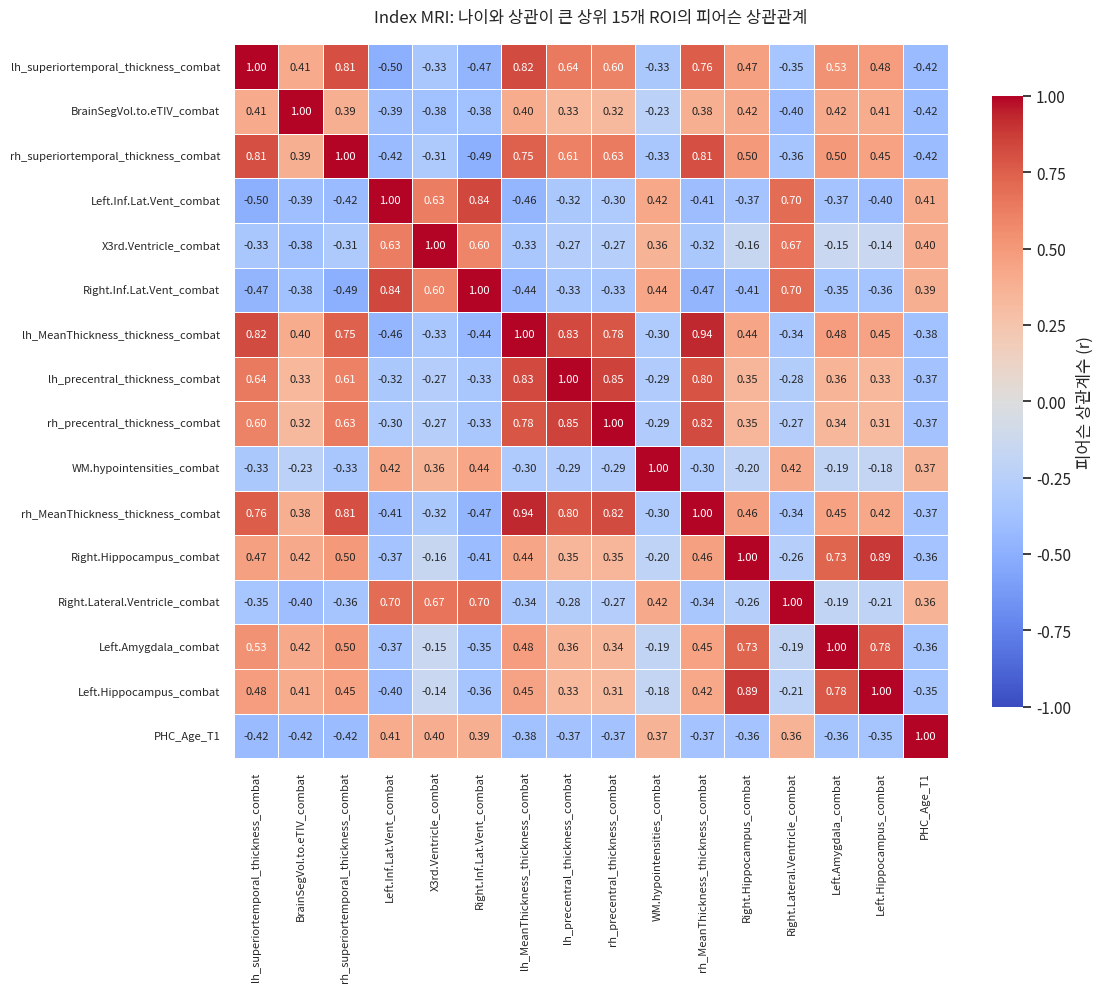

,순위,피어슨_r_나이,절대상관계수
lh_superiortemporal_thickness_combat,1,-0.424,0.424
BrainSegVol.to.eTIV_combat,2,-0.420,0.420
rh_superiortemporal_thickness_combat,3,-0.416,0.416
Left.Inf.Lat.Vent_combat,4,0.405,0.405
X3rd.Ventricle_combat,5,0.398,0.398
Right.Inf.Lat.Vent_combat,6,0.388,0.388
lh_MeanThickness_thickness_combat,7,-0.377,0.377
lh_precentral_thickness_combat,8,-0.374,0.374
rh_precentral_thickness_combat,9,-0.373,0.373
WM.hypointensities_combat,10,0.366,0.366


저장 파일:
- 02_전처리결과/전체ROI_피어슨상관행렬_제한자료.csv
- 02_전처리결과/ROI_나이상관_전체순위.csv
- 02_전처리결과/ROI_나이상관_상위15_상관행렬.csv
- 02_전처리결과/ROI_나이상관_상위15_히트맵.png


In [5]:
# 3.1 Index MRI 코호트의 ROI 상관관계를 저장하고, 연령 관련 상위 ROI 히트맵을 만듭니다.
# 전체 191개 ROI를 한 그림에 넣으면 읽기 어려우므로, 나이와의 절대 상관이 큰 상위 15개를 선택합니다.
AGE_COLUMN = "PHC_Age_T1"
ROI_HEATMAP_COUNT = 15

full_correlation = analysis_df[[*ROI_COLUMNS, AGE_COLUMN]].corr(method="pearson")
age_correlation_ranking = (
    full_correlation[AGE_COLUMN]
    .drop(index=AGE_COLUMN)
    .rename("피어슨_r_나이")
    .to_frame()
)
age_correlation_ranking["절대상관계수"] = age_correlation_ranking["피어슨_r_나이"].abs()
age_correlation_ranking = age_correlation_ranking.sort_values("절대상관계수", ascending=False)
age_correlation_ranking.insert(0, "순위", np.arange(1, len(age_correlation_ranking) + 1))

selected_roi_for_heatmap = age_correlation_ranking.head(ROI_HEATMAP_COUNT).index.tolist()
heatmap_columns = [*selected_roi_for_heatmap, AGE_COLUMN]
heatmap_correlation = full_correlation.loc[heatmap_columns, heatmap_columns]

full_correlation.to_csv(
    PREPROCESS_DIR / "전체ROI_피어슨상관행렬_제한자료.csv", encoding="utf-8-sig"
)
age_correlation_ranking.to_csv(
    PREPROCESS_DIR / "ROI_나이상관_전체순위.csv", encoding="utf-8-sig"
)
heatmap_correlation.to_csv(
    PREPROCESS_DIR / "ROI_나이상관_상위15_상관행렬.csv", encoding="utf-8-sig"
)

figure_size = max(11.5, len(heatmap_columns) * 0.72)
figure, axis = plt.subplots(figsize=(figure_size, figure_size * 0.86))
sns.heatmap(
    heatmap_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.45,
    linecolor="white",
    cbar_kws={"label": "피어슨 상관계수 (r)", "shrink": 0.82},
    ax=axis,
)
axis.set_title("Index MRI: 나이와 상관이 큰 상위 15개 ROI의 피어슨 상관관계", pad=16)
axis.set_xlabel("")
axis.set_ylabel("")
axis.tick_params(axis="x", labelrotation=90, labelsize=8)
axis.tick_params(axis="y", labelrotation=0, labelsize=8)
figure.tight_layout()
heatmap_path = PREPROCESS_DIR / "ROI_나이상관_상위15_히트맵.png"
figure.savefig(heatmap_path, dpi=190, bbox_inches="tight")
plt.show()

display(age_correlation_ranking.head(ROI_HEATMAP_COUNT).round(3))
print("저장 파일:")
print("- 02_전처리결과/전체ROI_피어슨상관행렬_제한자료.csv")
print("- 02_전처리결과/ROI_나이상관_전체순위.csv")
print("- 02_전처리결과/ROI_나이상관_상위15_상관행렬.csv")
print(f"- 02_전처리결과/{heatmap_path.name}")

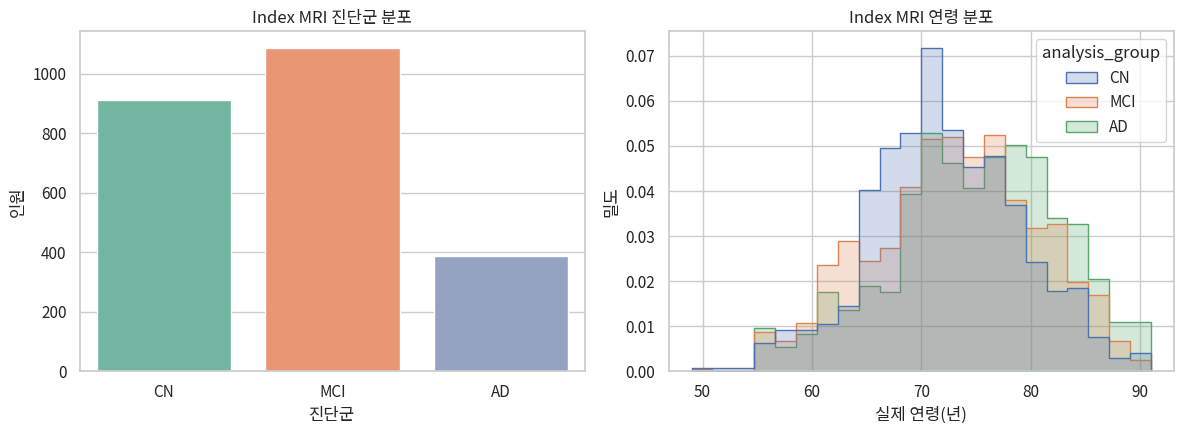

In [6]:
# 3.1 전처리 코호트의 진단군·연령 분포를 저장합니다.
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=analysis_df, x="analysis_group", order=["CN", "MCI", "AD"], ax=axes[0], palette="Set2")
axes[0].set(title="Index MRI 진단군 분포", xlabel="진단군", ylabel="인원")
sns.histplot(data=analysis_df, x="PHC_Age_T1", hue="analysis_group", bins=22, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set(title="Index MRI 연령 분포", xlabel="실제 연령(년)", ylabel="밀도")
figure.tight_layout()
figure.savefig(PREPROCESS_DIR / "전처리코호트_분포.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. 정상 노화 기준 Ridge 뇌 연령 모델

CN만으로 정상 노화 기준을 학습합니다. Ridge 회귀는 서로 상관이 높은 뇌 ROI의 계수를 안정화하며, 표형 신경영상 데이터에서 해석과 재현이 쉽습니다. 규제 강도 `alpha`는 훈련 CN 내부 5겹 교차검증으로 선택합니다.

In [7]:
# 4. CN을 RID 단위로 70/15/15 훈련·검증·독립 테스트로 분할합니다.
cn_df = analysis_df.loc[analysis_df["analysis_group"].eq("CN")].copy()
if len(cn_df) < 100:
    raise RuntimeError("CN 표본이 Ridge 모델 개발에 충분하지 않습니다.")

cn_df["_age_tertile"] = pd.qcut(
    cn_df["PHC_Age_T1"].rank(method="first"), q=3, labels=["young", "middle", "older"]
).astype(str)
cn_df["_stratum"] = cn_df["PHC_Sex"].astype(int).astype(str) + "_" + cn_df["_age_tertile"]
train_index, remaining_index = train_test_split(
    cn_df.index, test_size=0.30, random_state=RANDOM_SEED, stratify=cn_df["_stratum"]
)
validation_index, test_index = train_test_split(
    remaining_index, test_size=0.50, random_state=RANDOM_SEED,
    stratify=cn_df.loc[remaining_index, "_stratum"],
)
cn_df["model_split"] = ""
cn_df.loc[train_index, "model_split"] = "train"
cn_df.loc[validation_index, "model_split"] = "validation"
cn_df.loc[test_index, "model_split"] = "test"
analysis_df = analysis_df.merge(cn_df[["RID", "model_split"]], on="RID", how="left")

split_summary = (
    cn_df.groupby("model_split", observed=True)
    .agg(인원=("RID", "size"), 평균연령=("PHC_Age_T1", "mean"), 연령표준편차=("PHC_Age_T1", "std"), 여성비율=("PHC_Sex", lambda x: float((x == 2).mean())))
    .reset_index()
)
split_summary.to_csv(MODEL_DIR / "CN_훈련검증테스트_분할요약.csv", index=False, encoding="utf-8-sig")
display(split_summary.round(3))

X_train = cn_df.loc[cn_df["model_split"].eq("train"), FEATURE_COLUMNS]
y_train = cn_df.loc[cn_df["model_split"].eq("train"), "PHC_Age_T1"]
X_validation = cn_df.loc[cn_df["model_split"].eq("validation"), FEATURE_COLUMNS]
y_validation = cn_df.loc[cn_df["model_split"].eq("validation"), "PHC_Age_T1"]
X_test = cn_df.loc[cn_df["model_split"].eq("test"), FEATURE_COLUMNS]
y_test = cn_df.loc[cn_df["model_split"].eq("test"), "PHC_Age_T1"]

def make_ridge_pipeline(alpha: float = 1.0) -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("regressor", Ridge(alpha=alpha)),
    ])

,model_split,인원,평균연령,연령표준편차,여성비율
0,test,137,71.990,6.730,0.577
1,train,637,72.260,6.843,0.576
2,validation,137,72.263,6.873,0.577


In [8]:
# 4.1 Ridge 규제 강도(alpha)를 훈련 CN 내부 교차검증으로 선택합니다.
alpha_grid = np.logspace(-4, 7, 60)
ridge_search = GridSearchCV(
    estimator=make_ridge_pipeline(),
    param_grid={"regressor__alpha": alpha_grid},
    scoring="neg_mean_absolute_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)
with joblib.parallel_backend("threading"):
    ridge_search.fit(X_train, y_train)

selected_model = ridge_search.best_estimator_
validation_prediction = selected_model.predict(X_validation)
model_selection = pd.DataFrame({
    "alpha": ridge_search.cv_results_["param_regressor__alpha"].astype(float),
    "교차검증_MAE": -ridge_search.cv_results_["mean_test_score"],
    "교차검증_MAE_표준편차": ridge_search.cv_results_["std_test_score"],
}).sort_values("교차검증_MAE")
model_selection["선택됨"] = np.isclose(model_selection["alpha"], ridge_search.best_params_["regressor__alpha"])
model_selection.to_csv(MODEL_DIR / "Ridge_alpha_교차검증.csv", index=False, encoding="utf-8-sig")

print(f"선택 alpha: {ridge_search.best_params_['regressor__alpha']:.6g}")
print(f"훈련 내부 5겹 CV MAE: {-ridge_search.best_score_:.3f}년")
print(f"검증 MAE: {mean_absolute_error(y_validation, validation_prediction):.3f}년")
display(model_selection.head(10).round(4))

선택 alpha: 515.068
훈련 내부 5겹 CV MAE: 3.975년
검증 MAE: 4.007년


,alpha,교차검증_MAE,교차검증_MAE_표준편차,선택됨
36,515.0678,3.9754,0.2178,True
35,335.2924,3.9759,0.2257,False
37,791.2343,3.9941,0.2053,False
34,218.2645,3.9965,0.2284,False
38,1215.4743,4.0287,0.1973,False
33,142.0831,4.0299,0.2282,False
32,92.4915,4.0744,0.2268,False
39,1867.1811,4.0841,0.2027,False
31,60.2089,4.1340,0.2221,False
40,2868.3168,4.1660,0.2251,False


In [9]:
# 4.2 학습된 Ridge 계수를 저장합니다. 계수는 표준화된 입력값 기준입니다.
ridge_regressor = selected_model.named_steps["regressor"]
model_weights = pd.DataFrame({
    "변수": FEATURE_COLUMNS,
    "표준화_계수": ridge_regressor.coef_,
})
model_weights["절대계수"] = model_weights["표준화_계수"].abs()
model_weights = model_weights.sort_values("절대계수", ascending=False).reset_index(drop=True)
model_weights.to_csv(MODEL_DIR / "Ridge_변수별가중치.csv", index=False, encoding="utf-8-sig")
joblib.dump(selected_model, MODEL_DIR / "Ridge_뇌연령모델.joblib")

print(f"Ridge 절편: {ridge_regressor.intercept_:.3f}")
display(model_weights.head(20).round(4))

Ridge 절편: 72.260


,변수,표준화_계수,절대계수
0,X3rd.Ventricle_combat,0.5408,0.5408
1,WM.hypointensities_combat,0.5271,0.5271
2,Brain.Stem_combat,0.4389,0.4389
3,BrainSegVol.to.eTIV_combat,-0.4330,0.4330
4,rh_frontalpole_volume_combat,0.3972,0.3972
5,Left.Accumbens.area_combat,-0.3836,0.3836
6,Left.Inf.Lat.Vent_combat,0.3503,0.3503
7,Right.Inf.Lat.Vent_combat,0.3413,0.3413
8,rh_superiortemporal_thickness_combat,-0.2861,0.2861
9,Left.Amygdala_combat,-0.2855,0.2855


## 5. 연령 편향 보정과 BAG 계산

뇌 연령 회귀는 젊은 사람을 상대적으로 높게, 고령자를 상대적으로 낮게 예측하는 경향이 있습니다. 보정식은 **검증 CN만**으로 만들고, 독립 테스트·MCI·AD에는 같은 보정식을 그대로 적용합니다.

In [10]:
# 5. 검증 CN에서 연령 편향 보정식을 추정하고 모든 Index MRI에 적용합니다.
calibration_slope, calibration_intercept = np.polyfit(
    y_validation.to_numpy(), validation_prediction, deg=1
)
if abs(calibration_slope) < 1e-6:
    raise RuntimeError("보정 기울기가 0에 가까워 안정적으로 BAG를 보정할 수 없습니다.")

raw_prediction = selected_model.predict(analysis_df[FEATURE_COLUMNS])
results = analysis_df[[
    "RID", "PHC_SCANDATE", "analysis_group", "PHC_Diagnosis", "model_split", "PHC_Age_T1",
    "PHC_Sex", "PHC_Education", ICV_COLUMN, *PERSONAL_CLINICAL_COLUMNS,
]].copy()
results = results.rename(columns={
    "PHC_SCANDATE": "scan_date",
    "PHC_Age_T1": "chronological_age",
    "PHC_Sex": "sex",
    "PHC_Education": "education_years",
    ICV_COLUMN: "icv",
})
results["predicted_brain_age_raw"] = raw_prediction
results["raw_BAG"] = results["predicted_brain_age_raw"] - results["chronological_age"]
results["predicted_brain_age_corrected"] = (
    raw_prediction - calibration_intercept
) / calibration_slope
results["corrected_BAG"] = results["predicted_brain_age_corrected"] - results["chronological_age"]

calibration = {
    "equation": "raw_predicted_age = intercept + slope * chronological_age",
    "intercept": float(calibration_intercept),
    "slope": float(calibration_slope),
    "calibration_sample": "CN validation only",
    "random_seed": RANDOM_SEED,
}
(MODEL_DIR / "연령편향_보정계수.json").write_text(
    json.dumps(calibration, ensure_ascii=False, indent=2), encoding="utf-8"
)
results.to_csv(BAG_DIR / "RID별_보정BAG_제한자료.csv", index=False, encoding="utf-8-sig")
deidentified_results = results.drop(columns=["RID", "scan_date", "cdr_assessment_date", "first_ad_diagnosis_date"], errors="ignore").copy()
deidentified_results.insert(0, "analysis_row_id", rng.permutation(np.arange(1, len(deidentified_results) + 1)))
deidentified_results.to_csv(BAG_DIR / "비식별_뇌연령_BAG결과.csv", index=False, encoding="utf-8-sig")

print(f"보정식: raw_predicted_age = {calibration_intercept:.4f} + {calibration_slope:.6f} × actual_age")
print(f"최종 보정 BAG: (raw_predicted_age - {calibration_intercept:.4f}) / {calibration_slope:.6f} - actual_age")
display(results.head().round(3))

보정식: raw_predicted_age = 45.9786 + 0.360708 × actual_age
최종 보정 BAG: (raw_predicted_age - 45.9786) / 0.360708 - actual_age


,RID,scan_date,analysis_group,PHC_Diagnosis,model_split,chronological_age,sex,education_years,icv,sex_label_ko,...,cdr_sb,longitudinal_first_diagnosis,longitudinal_latest_diagnosis,first_ad_diagnosis_date,years_from_index_to_first_ad,ad_progression_status,predicted_brain_age_raw,raw_BAG,predicted_brain_age_corrected,corrected_BAG
0,2,2005-08-26,CN,1.0,train,74.5,1.0,16.0,1985235.039,남성,...,0.0,CN,MCI,NaT,NaN,AD 진단 기록 없음,76.726,2.226,85.242,10.742
1,4,2006-05-25,MCI,2.0,NaN,68.4,1.0,10.0,1685050.199,남성,...,0.5,MCI,MCI,NaT,NaN,AD 진단 기록 없음,73.134,4.734,75.282,6.882
2,5,2005-09-02,CN,1.0,train,73.8,1.0,16.0,1628964.477,남성,...,0.0,CN,CN,NaT,NaN,AD 진단 기록 없음,74.233,0.433,78.331,4.531
3,6,2005-11-15,MCI,2.0,NaN,80.5,2.0,13.0,1462431.692,여성,...,0.5,MCI,MCI,NaT,NaN,AD 진단 기록 없음,76.513,-3.987,84.651,4.151
4,7,2005-09-13,AD,3.0,NaN,75.5,1.0,10.0,1330152.932,남성,...,6.0,AD,AD,2005-10-06,0.063,Index MRI 시점 AD,77.001,1.501,86.004,10.504


In [11]:
# 5.1 독립 테스트 성능, 부트스트랩 신뢰구간, 순열검정을 계산합니다.
def metrics(y_true, y_pred) -> dict:
    return {
        "MAE_년": float(mean_absolute_error(y_true, y_pred)),
        "RMSE_년": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "R2": float(r2_score(y_true, y_pred)),
        "평균오차_년": float(np.mean(np.asarray(y_pred) - np.asarray(y_true))),
    }


performance_rows = []
for split in ["train", "validation", "test"]:
    split_frame = results.loc[(results["analysis_group"] == "CN") & (results["model_split"] == split)]
    performance_rows.append({"자료": split, "예측": "원시", **metrics(split_frame["chronological_age"], split_frame["predicted_brain_age_raw"])})
    performance_rows.append({"자료": split, "예측": "연령편향 보정", **metrics(split_frame["chronological_age"], split_frame["predicted_brain_age_corrected"])})
performance = pd.DataFrame(performance_rows)

test_frame = results.loc[(results["analysis_group"] == "CN") & (results["model_split"] == "test")]
test_y = test_frame["chronological_age"].to_numpy()
test_raw_prediction = test_frame["predicted_brain_age_raw"].to_numpy()
bootstrap_mae = []
for _ in range(2000):
    sample = rng.integers(0, len(test_y), len(test_y))
    bootstrap_mae.append(mean_absolute_error(test_y[sample], test_raw_prediction[sample]))

permutation_mae, permutation_r2 = [], []
for _ in range(500):
    permuted = clone(selected_model)
    permuted.fit(X_train, rng.permutation(y_train.to_numpy()))
    prediction = permuted.predict(X_test)
    permutation_mae.append(mean_absolute_error(y_test, prediction))
    permutation_r2.append(r2_score(y_test, prediction))
observed_raw = metrics(test_y, test_raw_prediction)
permutation_summary = {
    "permutations": 500,
    "raw_test_MAE_p_value": float((1 + np.sum(np.asarray(permutation_mae) <= observed_raw["MAE_년"])) / 501),
    "raw_test_R2_p_value": float((1 + np.sum(np.asarray(permutation_r2) >= observed_raw["R2"])) / 501),
    "test_MAE_95CI_low": float(np.quantile(bootstrap_mae, 0.025)),
    "test_MAE_95CI_high": float(np.quantile(bootstrap_mae, 0.975)),
}
performance.to_csv(MODEL_DIR / "훈련검증독립테스트_성능.csv", index=False, encoding="utf-8-sig")
(MODEL_DIR / "독립테스트_순열검정_부트스트랩.json").write_text(
    json.dumps(permutation_summary, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(performance.round(3))
print(json.dumps(permutation_summary, ensure_ascii=False, indent=2))

,자료,예측,MAE_년,RMSE_년,R2,평균오차_년
0,train,원시,3.547,4.515,0.564,0.000
1,train,연령편향 보정,6.657,8.509,-0.549,0.600
2,validation,원시,4.007,5.301,0.401,-0.218
3,validation,연령편향 보정,6.374,8.264,-0.456,-0.000
4,test,원시,3.680,4.540,0.542,0.233
5,test,연령편향 보정,6.569,8.576,-0.636,0.766


{
  "permutations": 500,
  "raw_test_MAE_p_value": 0.001996007984031936,
  "raw_test_R2_p_value": 0.001996007984031936,
  "test_MAE_95CI_low": 3.2320334977578358,
  "test_MAE_95CI_high": 4.132771015356791
}


## 6. 과적합 평가: 중첩 교차검증

독립 테스트 한 번의 결과만으로는 충분하지 않을 수 있습니다. 바깥쪽 5겹에서는 성능을 평가하고, 각 바깥쪽 훈련 세트 안에서만 Ridge `alpha`를 다시 선택하는 중첩 교차검증을 수행합니다.

In [12]:
# 6. 중첩 5겹 교차검증: 각 외부 테스트 폴드는 alpha 선택과 학습에 사용하지 않습니다.
cn_all = analysis_df.loc[analysis_df["analysis_group"].eq("CN")].reset_index(drop=True)
X_all = cn_all[FEATURE_COLUMNS]
y_all = cn_all["PHC_Age_T1"].to_numpy()
age_tertile = pd.qcut(cn_all["PHC_Age_T1"].rank(method="first"), q=3, labels=["young", "middle", "older"]).astype(str)
outer_strata = cn_all["PHC_Sex"].astype(int).astype(str) + "_" + age_tertile
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
outer_predictions = np.full(len(cn_all), np.nan)
nested_rows = []

for fold, (outer_train, outer_test) in enumerate(outer_cv.split(X_all, outer_strata), start=1):
    inner_search = GridSearchCV(
        estimator=make_ridge_pipeline(),
        param_grid={"regressor__alpha": alpha_grid},
        scoring="neg_mean_absolute_error",
        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED + fold),
        n_jobs=-1,
        refit=True,
    )
    with joblib.parallel_backend("threading"):
        inner_search.fit(X_all.iloc[outer_train], y_all[outer_train])
    train_prediction = inner_search.predict(X_all.iloc[outer_train])
    outer_prediction = inner_search.predict(X_all.iloc[outer_test])
    outer_predictions[outer_test] = outer_prediction
    nested_rows.append({
        "외부폴드": fold,
        "선택_alpha": float(inner_search.best_params_["regressor__alpha"]),
        "내부교차검증_MAE": -float(inner_search.best_score_),
        "외부훈련_MAE": float(mean_absolute_error(y_all[outer_train], train_prediction)),
        "외부테스트_MAE": float(mean_absolute_error(y_all[outer_test], outer_prediction)),
        "외부테스트_RMSE": float(mean_squared_error(y_all[outer_test], outer_prediction) ** 0.5),
        "외부테스트_R2": float(r2_score(y_all[outer_test], outer_prediction)),
    })

nested_results = pd.DataFrame(nested_rows)
nested_oof = metrics(y_all, outer_predictions)
nested_summary = pd.DataFrame([{
    "평가": "중첩교차검증 전체 OOF",
    **nested_oof,
    "폴드_테스트_MAE_평균": nested_results["외부테스트_MAE"].mean(),
    "폴드_테스트_MAE_표준편차": nested_results["외부테스트_MAE"].std(ddof=1),
    "훈련대비_테스트_MAE차이": (nested_results["외부테스트_MAE"] - nested_results["외부훈련_MAE"]).mean(),
}])
nested_results.to_csv(MODEL_DIR / "중첩교차검증_폴드결과.csv", index=False, encoding="utf-8-sig")
nested_summary.to_csv(MODEL_DIR / "중첩교차검증_요약.csv", index=False, encoding="utf-8-sig")

train_raw_mae = performance.loc[(performance["자료"] == "train") & (performance["예측"] == "원시"), "MAE_년"].iloc[0]
test_raw_mae = performance.loc[(performance["자료"] == "test") & (performance["예측"] == "원시"), "MAE_년"].iloc[0]
overfit_interpretation = (
    "독립 테스트와 중첩 교차검증 성능을 함께 제시했습니다. "
    "훈련 성능만으로 일반화 성능을 판단하지 않으며, 외부 코호트 검증 전에는 과적합이 완전히 없다고 단정하지 않습니다."
)
overfit_report = pd.DataFrame([{
    "훈련_원시_MAE": train_raw_mae,
    "독립테스트_원시_MAE": test_raw_mae,
    "훈련대비_독립테스트_MAE차이": test_raw_mae - train_raw_mae,
    "중첩CV_OOF_MAE": nested_oof["MAE_년"],
    "중첩CV_OOF_R2": nested_oof["R2"],
    "해석": overfit_interpretation,
}])
overfit_report.to_csv(MODEL_DIR / "과적합_점검요약.csv", index=False, encoding="utf-8-sig")
display(nested_results.round(3))
display(nested_summary.round(3))
display(overfit_report.round(3))

,외부폴드,선택_alpha,내부교차검증_MAE,외부훈련_MAE,외부테스트_MAE,외부테스트_RMSE,외부테스트_R2
0,1,335.292,3.818,3.398,4.059,5.090,0.462
1,2,515.068,3.815,3.457,4.072,5.361,0.423
2,3,335.292,3.939,3.448,3.759,4.757,0.441
3,4,335.292,3.832,3.393,3.913,4.953,0.519
4,5,515.068,4.002,3.585,3.556,4.595,0.506


,평가,MAE_년,RMSE_년,R2,평균오차_년,폴드_테스트_MAE_평균,폴드_테스트_MAE_표준편차,훈련대비_테스트_MAE차이
0,중첩교차검증 전체 OOF,3.872,4.959,0.471,0.032,3.872,0.217,0.416


,훈련_원시_MAE,독립테스트_원시_MAE,훈련대비_독립테스트_MAE차이,중첩CV_OOF_MAE,중첩CV_OOF_R2,해석
0,3.547,3.68,0.132,3.872,0.471,독립 테스트와 중첩 교차검증 성능을 함께 제시했습니다. 훈련 성능만으로 일반화 성능...


## 7. BAG 집단 비교

CN을 기준으로 MCI와 AD의 보정 BAG 차이를 비교합니다. 실제 연령, 성별, 교육연수, ICV를 함께 보정하며, 두 진단군 대비의 p값은 Holm 방법으로 보정합니다.

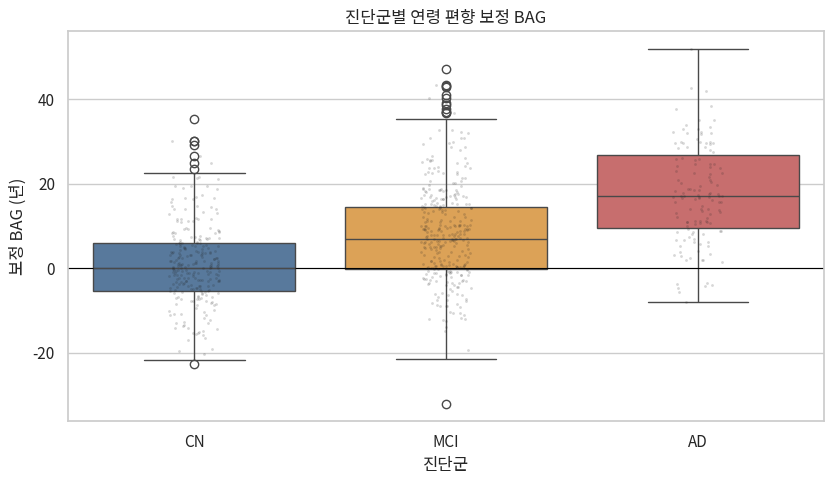

,analysis_group,인원,평균연령,평균교육연수,평균_보정BAG,보정BAG_표준편차,음성BAG_인원
0,CN,911,72.220,16.490,0.535,8.471,458
1,MCI,1088,73.073,16.002,7.496,11.066,278
2,AD,386,74.854,15.225,17.853,11.772,25


,대비,보정BAG_차이_년,95CI_하한,95CI_상한,p값,Holm_보정_p값,유의함_0_05
0,MCI - CN,6.3683,5.5015,7.2352,0.0,0.0,True
1,AD - CN,16.7214,15.3628,18.0799,0.0,0.0,True


In [13]:
# 7. CN, MCI, AD의 보정 BAG를 공변량 보정 선형모형으로 비교합니다.
comparison = results.copy()
comparison["analysis_group"] = pd.Categorical(comparison["analysis_group"], categories=["CN", "MCI", "AD"])
group_formula = (
    "corrected_BAG ~ C(analysis_group, Treatment(reference='CN')) + "
    "chronological_age + sex + education_years + icv"
)
group_model = smf.ols(group_formula, data=comparison).fit(cov_type="HC3")

contrast_rows = []
for group in ["MCI", "AD"]:
    term = next(name for name in group_model.params.index if f"T.{group}]" in name)
    interval = group_model.conf_int().loc[term]
    contrast_rows.append({
        "대비": f"{group} - CN",
        "보정BAG_차이_년": float(group_model.params[term]),
        "95CI_하한": float(interval.iloc[0]),
        "95CI_상한": float(interval.iloc[1]),
        "p값": float(group_model.pvalues[term]),
    })
group_inference = pd.DataFrame(contrast_rows)
group_inference["Holm_보정_p값"] = multipletests(group_inference["p값"], method="holm")[1]
group_inference["유의함_0_05"] = group_inference["Holm_보정_p값"] < 0.05

group_summary = comparison.groupby("analysis_group", observed=True).agg(
    인원=("RID", "size"), 평균연령=("chronological_age", "mean"), 평균교육연수=("education_years", "mean"),
    평균_보정BAG=("corrected_BAG", "mean"), 보정BAG_표준편차=("corrected_BAG", "std"),
    음성BAG_인원=("corrected_BAG", lambda x: int((x < 0).sum())),
).reset_index()
group_summary.to_csv(BAG_DIR / "집단별_보정BAG_요약.csv", index=False, encoding="utf-8-sig")
group_inference.to_csv(BAG_DIR / "집단간_보정BAG_공변량보정검정.csv", index=False, encoding="utf-8-sig")

figure, axis = plt.subplots(figsize=(8.5, 5))
sns.boxplot(data=comparison, x="analysis_group", y="corrected_BAG", order=["CN", "MCI", "AD"], palette=["#4c78a8", "#f2a541", "#d65f5f"], ax=axis)
draw = comparison.sample(min(len(comparison), 700), random_state=RANDOM_SEED)
sns.stripplot(data=draw, x="analysis_group", y="corrected_BAG", order=["CN", "MCI", "AD"], color="#222222", alpha=0.18, size=2, ax=axis)
axis.axhline(0, color="black", linewidth=0.8)
axis.set(title="진단군별 연령 편향 보정 BAG", xlabel="진단군", ylabel="보정 BAG (년)")
figure.tight_layout()
figure.savefig(BAG_DIR / "집단별_보정BAG_분포.png", dpi=180, bbox_inches="tight")
plt.show()

display(group_summary.round(3))
display(group_inference.round(4))

## 8. 취약 부위 분석

68개 피질 두께 ROI에서는 연령·성별·교육연수·ICV를 고려한 CN 기대값을 만든 뒤, 기대치보다 얇은 정도를 `aging_burden_z`로 계산합니다. 값이 클수록 더 얇은 방향입니다.

해마 용적, 내은피질·측두엽 두께, 뇌실 용적은 별도 표로도 확인합니다. 이 분석은 관찰자료의 집단 차이이며 인과 관계를 증명하지 않습니다.

In [14]:
# 8. ROI별 CN 기준 노화 부담과 진단군 차이를 계산합니다.
CORTICAL_THICKNESS = [
    column for column in ROI_COLUMNS
    if column.startswith(("lh_", "rh_")) and "_thickness_combat" in column and "MeanThickness" not in column
]
if len(CORTICAL_THICKNESS) != 68:
    raise RuntimeError(f"예상한 68개 피질 두께 ROI와 다릅니다: {len(CORTICAL_THICKNESS)}")

normative_train = analysis_df.loc[
    (analysis_df["analysis_group"] == "CN") & (analysis_df["model_split"] == "train")
].copy()
covariates = ["PHC_Age_T1", "PHC_Sex", "PHC_Education", ICV_COLUMN]
map_cohort = analysis_df.copy()
regional_rows = []

def parcel_name(column: str) -> tuple[str, str]:
    hemisphere = "left" if column.startswith("lh_") else "right"
    parcel = column.replace("lh_", "").replace("rh_", "").replace("_thickness_combat", "")
    return hemisphere, parcel

for roi in CORTICAL_THICKNESS:
    normative_model = LinearRegression().fit(normative_train[covariates], normative_train[roi])
    reference_residual = normative_train[roi] - normative_model.predict(normative_train[covariates])
    reference_sd = float(reference_residual.std(ddof=1))
    if not np.isfinite(reference_sd) or reference_sd <= 1e-10:
        continue
    frame = map_cohort[["analysis_group", *covariates]].copy()
    expected = normative_model.predict(map_cohort[covariates])
    frame["aging_burden_z"] = -(map_cohort[roi].to_numpy() - expected) / reference_sd
    model = smf.ols(
        f"aging_burden_z ~ C(analysis_group, Treatment(reference='CN')) + PHC_Age_T1 + PHC_Sex + PHC_Education + {ICV_COLUMN}",
        data=frame,
    ).fit(cov_type="HC3")
    hemisphere, parcel = parcel_name(roi)
    for group in ["MCI", "AD"]:
        term = next(name for name in model.params.index if f"T.{group}]" in name)
        interval = model.conf_int().loc[term]
        regional_rows.append({
            "ROI": roi,
            "반구": hemisphere,
            "parcel": parcel,
            "대비": f"{group} - CN",
            "더얇은방향_효과크기_z": float(model.params[term]),
            "95CI_하한": float(interval.iloc[0]),
            "95CI_상한": float(interval.iloc[1]),
            "p값": float(model.pvalues[term]),
        })

regional_stats = pd.DataFrame(regional_rows)
regional_stats["FDR_q값"] = multipletests(regional_stats["p값"], method="fdr_bh")[1]
regional_stats["FDR_유의_0_05"] = regional_stats["FDR_q값"] < 0.05
regional_stats.to_csv(BAG_DIR / "피질_취약부위_집단통계.csv", index=False, encoding="utf-8-sig")

# 연구 가설의 핵심 구조를 표에서 함께 확인합니다. 뇌실은 큰 방향, 나머지는 작은 방향이 취약성입니다.
priority_rois = {
    "좌 해마 용적": ("Left.Hippocampus_combat", "low"),
    "우 해마 용적": ("Right.Hippocampus_combat", "low"),
    "좌 내은피질 두께": ("lh_entorhinal_thickness_combat", "low"),
    "우 내은피질 두께": ("rh_entorhinal_thickness_combat", "low"),
    "좌 하측두엽 두께": ("lh_inferiortemporal_thickness_combat", "low"),
    "우 하측두엽 두께": ("rh_inferiortemporal_thickness_combat", "low"),
    "좌 측뇌실 용적": ("Left.Lateral.Ventricle_combat", "high"),
    "우 측뇌실 용적": ("Right.Lateral.Ventricle_combat", "high"),
}
priority_rows = []
for label, (roi, direction) in priority_rois.items():
    reference_model = LinearRegression().fit(normative_train[covariates], normative_train[roi])
    reference_residual = normative_train[roi] - reference_model.predict(normative_train[covariates])
    reference_sd = float(reference_residual.std(ddof=1))
    expected = reference_model.predict(map_cohort[covariates])
    value = (map_cohort[roi].to_numpy() - expected) / reference_sd
    burden = -value if direction == "low" else value
    frame = map_cohort[["analysis_group", *covariates]].copy()
    frame["aging_burden_z"] = burden
    model = smf.ols(
        f"aging_burden_z ~ C(analysis_group, Treatment(reference='CN')) + PHC_Age_T1 + PHC_Sex + PHC_Education + {ICV_COLUMN}",
        data=frame,
    ).fit(cov_type="HC3")
    for group in ["MCI", "AD"]:
        term = next(name for name in model.params.index if f"T.{group}]" in name)
        priority_rows.append({
            "취약부위": label,
            "ROI": roi,
            "취약방향": "작을수록 취약" if direction == "low" else "클수록 취약",
            "대비": f"{group} - CN",
            "노화부담_효과크기_z": float(model.params[term]),
            "p값": float(model.pvalues[term]),
        })
priority_stats = pd.DataFrame(priority_rows)
priority_stats["FDR_q값"] = multipletests(priority_stats["p값"], method="fdr_bh")[1]
priority_stats["FDR_유의_0_05"] = priority_stats["FDR_q값"] < 0.05
priority_stats.to_csv(BAG_DIR / "해마_내은피질_측두엽_뇌실_통계.csv", index=False, encoding="utf-8-sig")

top_regions = regional_stats.sort_values("더얇은방향_효과크기_z", ascending=False).groupby("대비", as_index=False).head(12)
display(top_regions.round(4))
display(priority_stats.round(4))

,ROI,반구,parcel,대비,더얇은방향_효과크기_z,95CI_하한,95CI_상한,p값,FDR_q값,FDR_유의_0_05
9,lh_entorhinal_thickness_combat,left,entorhinal,AD - CN,2.1223,1.9410,2.3035,0.0,0.0,True
77,rh_entorhinal_thickness_combat,right,entorhinal,AD - CN,1.8750,1.7085,2.0414,0.0,0.0,True
31,lh_middletemporal_thickness_combat,left,middletemporal,AD - CN,1.6396,1.4565,1.8227,0.0,0.0,True
99,rh_middletemporal_thickness_combat,right,middletemporal,AD - CN,1.5299,1.3596,1.7002,0.0,0.0,True
13,lh_fusiform_thickness_combat,left,fusiform,AD - CN,1.5011,1.3215,1.6806,0.0,0.0,True
17,lh_inferiortemporal_thickness_combat,left,inferiortemporal,AD - CN,1.4816,1.3104,1.6529,0.0,0.0,True
61,lh_superiortemporal_thickness_combat,left,superiortemporal,AD - CN,1.3695,1.2145,1.5245,0.0,0.0,True
81,rh_fusiform_thickness_combat,right,fusiform,AD - CN,1.3463,1.1764,1.5162,0.0,0.0,True
85,rh_inferiortemporal_thickness_combat,right,inferiortemporal,AD - CN,1.3418,1.1777,1.5058,0.0,0.0,True
15,lh_inferiorparietal_thickness_combat,left,inferiorparietal,AD - CN,1.3033,1.1289,1.4776,0.0,0.0,True


,취약부위,ROI,취약방향,대비,노화부담_효과크기_z,p값,FDR_q값,FDR_유의_0_05
0,좌 해마 용적,Left.Hippocampus_combat,작을수록 취약,MCI - CN,0.8336,0.0,0.0,True
1,좌 해마 용적,Left.Hippocampus_combat,작을수록 취약,AD - CN,2.0188,0.0,0.0,True
2,우 해마 용적,Right.Hippocampus_combat,작을수록 취약,MCI - CN,0.8094,0.0,0.0,True
3,우 해마 용적,Right.Hippocampus_combat,작을수록 취약,AD - CN,1.9021,0.0,0.0,True
4,좌 내은피질 두께,lh_entorhinal_thickness_combat,작을수록 취약,MCI - CN,0.7221,0.0,0.0,True
5,좌 내은피질 두께,lh_entorhinal_thickness_combat,작을수록 취약,AD - CN,2.1223,0.0,0.0,True
6,우 내은피질 두께,rh_entorhinal_thickness_combat,작을수록 취약,MCI - CN,0.6459,0.0,0.0,True
7,우 내은피질 두께,rh_entorhinal_thickness_combat,작을수록 취약,AD - CN,1.8750,0.0,0.0,True
8,좌 하측두엽 두께,lh_inferiortemporal_thickness_combat,작을수록 취약,MCI - CN,0.4624,0.0,0.0,True
9,좌 하측두엽 두께,lh_inferiortemporal_thickness_combat,작을수록 취약,AD - CN,1.4816,0.0,0.0,True


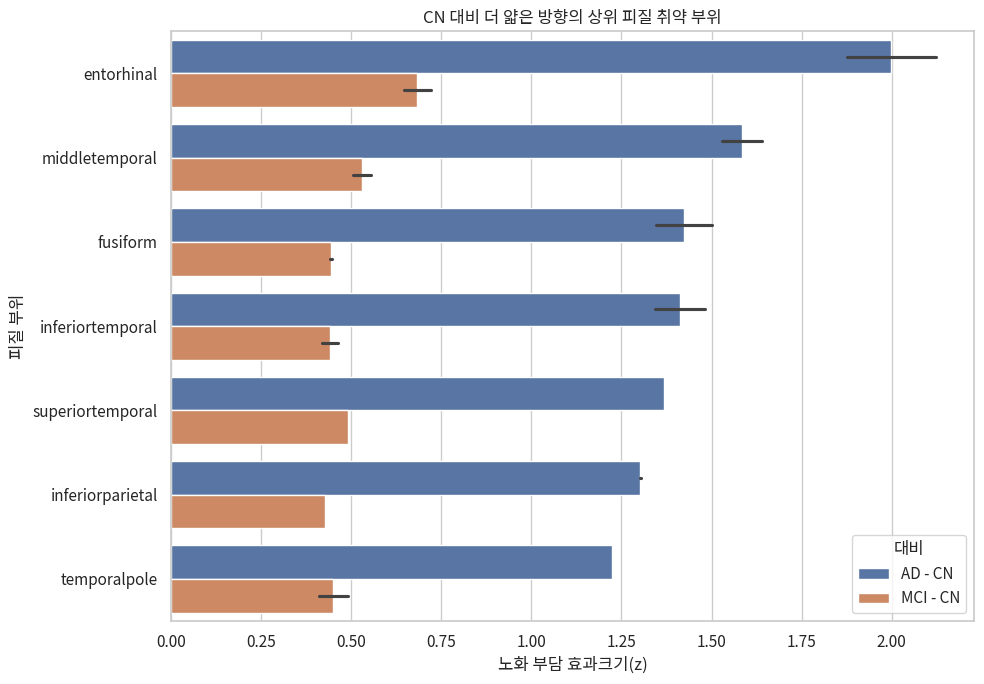

In [15]:
# 8.1 각 대비에서 더 얇은 방향의 상위 피질 부위를 그림으로 저장합니다.
plot_regions = regional_stats.loc[regional_stats["더얇은방향_효과크기_z"].gt(0)].copy()
plot_regions = plot_regions.sort_values(["대비", "더얇은방향_효과크기_z"], ascending=[True, False])
plot_regions = plot_regions.groupby("대비", as_index=False).head(12)
figure, axis = plt.subplots(figsize=(10, 7))
sns.barplot(data=plot_regions, y="parcel", x="더얇은방향_효과크기_z", hue="대비", ax=axis)
axis.set(title="CN 대비 더 얇은 방향의 상위 피질 취약 부위", xlabel="노화 부담 효과크기(z)", ylabel="피질 부위")
figure.tight_layout()
figure.savefig(BAG_DIR / "상위_피질취약부위.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. 집단별 취약 부위 3D 렌더링

3D 표면은 표준 `fsaverage5` 뇌 표면입니다. 색은 개인 한 명의 영상이나 실제 개인 뇌 형태가 아니라, CN 대비 집단 차이의 통계 효과크기를 나타냅니다.

- 빨강: CN보다 피질 두께 감소 부담이 큰 부위
- 파랑: CN보다 피질 두께 감소 부담이 작은 부위
- 흰 선: Desikan-Killiany 피질 구획 경계

이 집단 지도와 별개로, 다음 장에서 **RID별 개인 지도**를 만듭니다.

In [16]:
# 9. 표준 FreeSurfer 표면에 MCI-CN, AD-CN 피질 취약 부위를 렌더링합니다.
import nibabel as nib
import plotly.graph_objects as go
from nilearn import datasets, surface

annotation_dir = ASSET_DIR / "fsaverage5"
left_annotation = annotation_dir / "left.aparc.annot"
right_annotation = annotation_dir / "right.aparc.annot"
if not (left_annotation.is_file() and right_annotation.is_file()):
    raise FileNotFoundError(
        "fsaverage5 annotation 파일이 없습니다. assets/fsaverage5에 left.aparc.annot와 right.aparc.annot가 필요합니다."
    )

fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage5", data_dir=str(ASSET_DIR))

def load_surface(hemisphere: str):
    mesh_path = fsaverage.pial_left if hemisphere == "left" else fsaverage.pial_right
    annotation_path = left_annotation if hemisphere == "left" else right_annotation
    coordinates, faces = surface.load_surf_mesh(mesh_path)
    labels, _, names = nib.freesurfer.read_annot(str(annotation_path))
    decoded_names = [name.decode("utf-8") if isinstance(name, bytes) else str(name) for name in names]
    return coordinates, faces.astype(int), labels, decoded_names


def parcel_vertex_values(frame: pd.DataFrame, hemisphere: str, labels, names):
    lookup = frame.loc[frame["반구"].eq(hemisphere)].set_index("parcel")["더얇은방향_효과크기_z"].to_dict()
    values = np.full(len(labels), np.nan)
    for index, parcel in enumerate(names):
        if parcel in lookup:
            values[labels == index] = lookup[parcel]
    return values


def parcel_boundaries(coordinates, faces, labels):
    edges = np.vstack([faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [0, 2]]])
    edges.sort(axis=1)
    edges = np.unique(edges, axis=0)
    edges = edges[labels[edges[:, 0]] != labels[edges[:, 1]]]
    segments = coordinates[edges]
    return go.Scatter3d(
        x=np.column_stack([segments[:, 0, 0], segments[:, 1, 0], np.full(len(edges), np.nan)]).ravel(),
        y=np.column_stack([segments[:, 0, 1], segments[:, 1, 1], np.full(len(edges), np.nan)]).ravel(),
        z=np.column_stack([segments[:, 0, 2], segments[:, 1, 2], np.full(len(edges), np.nan)]).ravel(),
        mode="lines", hoverinfo="skip", showlegend=False,
        line={"color": "rgba(255,255,255,0.60)", "width": 1},
    )


def colors(values, limit=1.5):
    normalizer = mpl.colors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    colormap = mpl.colormaps["RdBu_r"]
    return [mpl.colors.to_hex(colormap(normalizer(value))) if np.isfinite(value) else "#b9b9b9" for value in values]


def save_group_map(contrast: str, hemisphere: str, camera_eye: dict):
    map_frame = regional_stats.loc[regional_stats["대비"].eq(contrast)].copy()
    coordinates, faces, labels, names = load_surface(hemisphere)
    values = parcel_vertex_values(map_frame, hemisphere, labels, names)
    mesh = go.Mesh3d(
        x=coordinates[:, 0], y=coordinates[:, 1], z=coordinates[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        vertexcolor=colors(values), flatshading=True, hoverinfo="skip", showlegend=False,
        lighting={"ambient": 0.52, "diffuse": 0.78, "specular": 0.12, "roughness": 0.88},
        lightposition={"x": 100, "y": 200, "z": 100},
    )
    colorbar = go.Scatter3d(
        x=[None, None], y=[None, None], z=[None, None], mode="markers", hoverinfo="skip", showlegend=False,
        marker={"size": 0.1, "color": [-1.5, 1.5], "colorscale": "RdBu_r", "cmin": -1.5, "cmax": 1.5,
                "showscale": True, "colorbar": {"title": "CN 대비 얇아짐 효과(z)", "thickness": 18, "len": 0.72}},
    )
    hemisphere_label = "좌반구" if hemisphere == "left" else "우반구"
    figure = go.Figure(data=[mesh, parcel_boundaries(coordinates, faces, labels), colorbar])
    figure.update_layout(
        title=f"{contrast} | {hemisphere_label} 피질 취약 부위 지도",
        paper_bgcolor="white", plot_bgcolor="white", margin={"l": 0, "r": 0, "t": 65, "b": 0},
        scene={
            "xaxis": {"visible": False}, "yaxis": {"visible": False}, "zaxis": {"visible": False},
            "bgcolor": "white", "aspectmode": "data",
            "camera": {"eye": camera_eye, "up": {"x": 0, "y": 0, "z": 1}},
        },
    )
    safe_contrast = contrast.replace(" - ", "_대_")
    filename = RENDER_DIR / f"{safe_contrast}_{hemisphere_label}_피질취약부위.html"
    figure.write_html(str(filename), include_plotlyjs=True, full_html=True, auto_open=False)
    return filename


rendered_maps = []
for contrast in ["MCI - CN", "AD - CN"]:
    rendered_maps.append(save_group_map(contrast, "left", {"x": -1.8, "y": 0.2, "z": 0.2}))
    rendered_maps.append(save_group_map(contrast, "right", {"x": 1.8, "y": 0.2, "z": 0.2}))
print("생성된 3D 지도:")
for path in rendered_maps:
    print(path.name)

생성된 3D 지도:
MCI_대_CN_좌반구_피질취약부위.html
MCI_대_CN_우반구_피질취약부위.html
AD_대_CN_좌반구_피질취약부위.html
AD_대_CN_우반구_피질취약부위.html


## 10. RID별 개인 3D 뇌 노화 지도, BAG 및 임상 정보 조회

이 장은 원하는 **RID**를 입력하면 그 사람의 가장 이른 유효 T1 MRI(Index MRI)를 사용하여 다음을 함께 만듭니다.

1. 실제 나이, 성별, 예측 뇌연령, 보정 BAG
2. 원본 `PHC_Diagnosis` 코드와 MRI 시점 진단 단계(`1=CN`, `2=MCI`, `3=AD`), DXSUM 기반의 추적 진단 이력
3. MRI와 가장 가까운 365일 이내 CDR Global 및 CDR-SB 임상 중증도 평가
4. CN 훈련군에서 같은 나이·성별·교육연수·ICV를 고려해 기대한 피질 두께와의 차이
5. 좌·우반구의 3D 피질 지도와 상위 취약 부위 표

`CDR Global`은 전반적 인지·기능 저하의 임상 중증도(0=정상, 0.5=매우 경도, 1=경도, 2=중등도, 3=중증)이며, `CDR-SB`는 6개 영역 점수를 합친 값입니다. CDR은 **개인 결과 표시용**이고 Ridge 뇌연령/BAG 모델의 입력에는 사용하지 않았습니다. CDR이 MRI 전후 365일 안에 없으면 `연결된 CDR 평가 없음`으로 표시합니다.

중요한 제한: CDR은 인지 저하 중증도를 보여 주지만 BAG 자체나 단일 MRI만으로 AD의 진행 속도 또는 확정 진단을 정하지 않습니다. 현재 AD 상태와 추적 진단 이력은 설명용 정보이며, 연구용 분석 결과로 해석해야 합니다.

현재 ADNI 제공 파일은 FreeSurfer의 *부위별 수치 표*이므로, 지도는 개인의 실제 MRI 기하학적 표면을 재구성한 것이 아닙니다. 개인별 부위 수치를 표준 `fsaverage5` 표면의 해당 구획에 투영한 **개인별 정량 지도**입니다.

## 10.1 모든 RID의 개인 피질 노화 부담 점수 준비

RID별 지도를 만들기 전, 모든 Index MRI에 대해 나이·성별·교육연수·ICV를 고려한 CN 기준 피질 두께 기대값과의 차이를 z 점수로 계산합니다. 크릴수록 기대치보다 얇은 방향의 부담이 큽니다.

In [17]:
# 10.1 CN 훈련군 기준의 개인별 피질 노화 부담 점수를 모든 Index MRI에 계산합니다.
# 이 표를 먼저 저장해 두므로, RID를 선택할 때 모델을 다시 학습하지 않습니다.
personal_burden_values = {}
for roi in CORTICAL_THICKNESS:
    reference_model = LinearRegression().fit(normative_train[covariates], normative_train[roi])
    reference_residual = normative_train[roi] - reference_model.predict(normative_train[covariates])
    reference_sd = float(reference_residual.std(ddof=1))
    if not np.isfinite(reference_sd) or reference_sd <= 1e-10:
        raise RuntimeError(f"개인 지도 기준편차가 유효하지 않습니다: {roi}")
    expected = reference_model.predict(analysis_df[covariates])
    personal_burden_values[roi] = -(analysis_df[roi].to_numpy() - expected) / reference_sd

personal_surface_scores = results[[
    "RID", "scan_date", "analysis_group", "PHC_Diagnosis", "chronological_age", "sex",
    "predicted_brain_age_raw", "predicted_brain_age_corrected", "corrected_BAG", *PERSONAL_CLINICAL_COLUMNS,
]].copy()
for roi in CORTICAL_THICKNESS:
    personal_surface_scores[roi] = personal_burden_values[roi]
personal_surface_scores = personal_surface_scores.sort_values("RID").reset_index(drop=True)

if not personal_surface_scores["RID"].is_unique or len(personal_surface_scores) != len(analysis_df):
    raise RuntimeError("RID별 개인 지도 점수의 행 수 또는 RID 고유성이 올바르지 않습니다.")

personal_scores_path = PERSONAL_RENDER_DIR / "RID별_개인_피질노화부담_Z점수_제한자료.csv"
personal_surface_scores.to_csv(personal_scores_path, index=False, encoding="utf-8-sig")
print(f"RID {len(personal_surface_scores):,}명의 개인 지도 점수를 생성했습니다.")
print("각 RID를 검색하면 이 표의 해당 행을 표준 뇌 표면에 투영합니다.")
display(personal_surface_scores[[
    "RID", "scan_date", "analysis_group", "PHC_Diagnosis", "chronological_age", "sex_label_ko",
    "predicted_brain_age_corrected", "corrected_BAG", "cdr_global", "cdr_sb", "ad_progression_status",
]].head().round(3))

RID 2,385명의 개인 지도 점수를 생성했습니다.
각 RID를 검색하면 이 표의 해당 행을 표준 뇌 표면에 투영합니다.


,RID,scan_date,analysis_group,PHC_Diagnosis,chronological_age,sex_label_ko,predicted_brain_age_corrected,corrected_BAG,cdr_global,cdr_sb,ad_progression_status
0,2,2005-08-26,CN,1.0,74.5,남성,85.242,10.742,0.0,0.0,AD 진단 기록 없음
1,4,2006-05-25,MCI,2.0,68.4,남성,75.282,6.882,0.5,0.5,AD 진단 기록 없음
2,5,2005-09-02,CN,1.0,73.8,남성,78.331,4.531,0.0,0.0,AD 진단 기록 없음
3,6,2005-11-15,MCI,2.0,80.5,여성,84.651,4.151,0.5,0.5,AD 진단 기록 없음
4,7,2005-09-13,AD,3.0,75.5,남성,86.004,10.504,1.0,6.0,Index MRI 시점 AD


In [18]:
# 10.1 RID 선택 시 개인별 3D HTML과 BAG 요약을 생성하는 함수 및 검색 화면입니다.
from IPython.display import clear_output
import ipywidgets as widgets
from uuid import uuid4

PERSONAL_MAP_LIMIT_Z = 2.5
PERSONAL_OUTPUT_CACHE: dict[int, dict[str, Path]] = {}
PHC_DIAGNOSIS_LABELS_KO = {1: "CN (정상 인지)", 2: "MCI (경도인지장애)", 3: "AD (알츠하이머병)"}


# Windows/OneDrive에서는 큰 Plotly HTML 문자열을 한 번에 쓰면 OSError가 날 수 있습니다.
# Plotly JavaScript는 한 번만 저장하고, 각 지도 HTML은 작은 청크로 나누어 기록합니다.
PLOTLY_JS_FILENAME = "plotly.min.js"

def write_text_in_chunks(path: Path, text: str, chunk_size: int = 512_000):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="\n") as handle:
        for start in range(0, len(text), chunk_size):
            handle.write(text[start:start + chunk_size])


def write_personal_plotly_html(figure, output_path: Path):
    from plotly.offline import get_plotlyjs

    javascript_path = PERSONAL_OUTPUT_DIR / PLOTLY_JS_FILENAME
    if not javascript_path.is_file() or javascript_path.stat().st_size < 1_000_000:
        write_text_in_chunks(javascript_path, get_plotlyjs())
    html = figure.to_html(include_plotlyjs=PLOTLY_JS_FILENAME, full_html=True)
    write_text_in_chunks(output_path, html)

def personal_vertex_values(rid: int, hemisphere: str, labels, names):
    row = personal_surface_scores.loc[personal_surface_scores["RID"].eq(rid)]
    if len(row) != 1:
        raise KeyError(f"RID {rid}의 Index MRI 결과가 없습니다.")
    score_row = row.iloc[0]
    prefix = "lh" if hemisphere == "left" else "rh"
    values = np.full(len(labels), np.nan)
    for index, parcel in enumerate(names):
        roi = f"{prefix}_{parcel}_thickness_combat"
        if roi in score_row.index:
            values[labels == index] = float(score_row[roi])
    return values


def make_personal_map(rid: int, hemisphere: str, camera_eye: dict):
    row = personal_surface_scores.loc[personal_surface_scores["RID"].eq(rid)].iloc[0]
    coordinates, faces, labels, names = load_surface(hemisphere)
    values = personal_vertex_values(rid, hemisphere, labels, names)
    mesh = go.Mesh3d(
        x=coordinates[:, 0], y=coordinates[:, 1], z=coordinates[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        vertexcolor=colors(values, limit=PERSONAL_MAP_LIMIT_Z),
        flatshading=True, hoverinfo="skip", showlegend=False,
        lighting={"ambient": 0.52, "diffuse": 0.78, "specular": 0.12, "roughness": 0.88},
        lightposition={"x": 100, "y": 200, "z": 100},
    )
    colorbar = go.Scatter3d(
        x=[None, None], y=[None, None], z=[None, None], mode="markers", hoverinfo="skip", showlegend=False,
        marker={
            "size": 0.1, "color": [-PERSONAL_MAP_LIMIT_Z, PERSONAL_MAP_LIMIT_Z],
            "colorscale": "RdBu_r", "cmin": -PERSONAL_MAP_LIMIT_Z, "cmax": PERSONAL_MAP_LIMIT_Z,
            "showscale": True,
            "colorbar": {"title": "개인 피질 노화 부담 (z)", "thickness": 18, "len": 0.72},
        },
    )
    hemisphere_label = "좌반구" if hemisphere == "left" else "우반구"
    figure = go.Figure(data=[mesh, parcel_boundaries(coordinates, faces, labels), colorbar])
    figure.update_layout(
        title=(
            f"RID {rid} | {hemisphere_label} 개인 피질 노화 지도 | "
            f"PHC_Diagnosis {int(row['PHC_Diagnosis'])} ({row['analysis_group']}) | 보정 BAG {row['corrected_BAG']:+.2f}세"
        ),
        paper_bgcolor="white", plot_bgcolor="white", margin={"l": 0, "r": 0, "t": 65, "b": 0},
        scene={
            "xaxis": {"visible": False}, "yaxis": {"visible": False}, "zaxis": {"visible": False},
            "bgcolor": "white", "aspectmode": "data",
            "camera": {"eye": camera_eye, "up": {"x": 0, "y": 0, "z": 1}},
        },
    )
    return figure


def generate_rid_brain_map(rid: int, save_html: bool = True):
    # RID의 Index MRI 기준 BAG와 좌·우반구 개인 3D 지도를 생성합니다.
    try:
        rid = int(rid)
    except (TypeError, ValueError) as error:
        raise ValueError("RID는 정수로 입력해야 합니다.") from error

    selected = personal_surface_scores.loc[personal_surface_scores["RID"].eq(rid)]
    if len(selected) != 1:
        raise KeyError(
            f"RID {rid}는 유효 Index MRI 분석 코호트에 없습니다. "
            "전처리 과정에서 필수 입력값 누락, 유효성 기준 미충족, 또는 다른 RID의 더 이른 유효 촬영이 선택된 경우일 수 있습니다."
        )

    row = selected.iloc[0]
    region_rows = []
    for roi in CORTICAL_THICKNESS:
        hemisphere, parcel = parcel_name(roi)
        region_rows.append({
            "RID": rid,
            "반구": "좌반구" if hemisphere == "left" else "우반구",
            "피질 구획": parcel,
            "개인 피질 노화 부담 z": float(row[roi]),
        })
    top_regions = pd.DataFrame(region_rows).sort_values("개인 피질 노화 부담 z", ascending=False).head(12)

    def optional_number(value, digits=2):
        return "연결된 CDR 평가 없음" if pd.isna(value) else round(float(value), digits)

    def optional_date(value):
        return "기록 없음" if pd.isna(value) else pd.Timestamp(value).strftime("%Y-%m-%d")

    diagnosis_history = (
        f"{row['longitudinal_first_diagnosis']} → {row['longitudinal_latest_diagnosis']}"
        if pd.notna(row["longitudinal_first_diagnosis"]) and pd.notna(row["longitudinal_latest_diagnosis"])
        else "진단 이력 없음"
    )
    summary = pd.DataFrame([{
        "RID": rid,
        "Index MRI 촬영일": optional_date(row["scan_date"]),
        "실제 나이": float(row["chronological_age"]),
        "성별": row["sex_label_ko"],
        "PHC_Diagnosis 원본 코드": int(row["PHC_Diagnosis"]),
        "PHC_Diagnosis 진행 단계": PHC_DIAGNOSIS_LABELS_KO.get(int(row["PHC_Diagnosis"]), "알 수 없음"),
        "MRI 시점 임상 단계": row["analysis_group"],
        "원시 예측 뇌연령": float(row["predicted_brain_age_raw"]),
        "보정 예측 뇌연령": float(row["predicted_brain_age_corrected"]),
        "보정 BAG": float(row["corrected_BAG"]),
        "CDR 평가일": optional_date(row["cdr_assessment_date"]),
        "MRI-CDR 간격(일)": optional_number(row["cdr_days_from_mri"], 0),
        "CDR Global": optional_number(row["cdr_global"], 1),
        "CDR Global 해석": row["cdr_global_label"],
        "CDR-SB": optional_number(row["cdr_sb"], 1),
        "추적 진단 이력": diagnosis_history,
        "최초 AD 진단일": optional_date(row["first_ad_diagnosis_date"]),
        "AD 진행 정보": row["ad_progression_status"],
    }])
    left_figure = make_personal_map(rid, "left", {"x": -1.8, "y": 0.2, "z": 0.2})
    right_figure = make_personal_map(rid, "right", {"x": 1.8, "y": 0.2, "z": 0.2})

    output_paths = {}
    if save_html:
        cached_paths = PERSONAL_OUTPUT_CACHE.get(rid)
        if cached_paths is not None and all(path.is_file() for path in cached_paths.values()):
            return summary, top_regions, left_figure, right_figure, cached_paths
        # OneDrive 동기화 중 열린 HTML을 덮어쓰지 않도록, 매 생성마다 고유 파일명을 사용합니다.
        output_id = f"{datetime.now():%Y%m%d_%H%M%S_%f}_{uuid4().hex[:6]}"
        left_path = PERSONAL_OUTPUT_DIR / f"RID_{rid}_{output_id}_left_personal_aging_map.html"
        right_path = PERSONAL_OUTPUT_DIR / f"RID_{rid}_{output_id}_right_personal_aging_map.html"
        top_path = PERSONAL_OUTPUT_DIR / f"RID_{rid}_{output_id}_top_cortical_regions.csv"
        summary_path = PERSONAL_OUTPUT_DIR / f"RID_{rid}_{output_id}_BAG_summary.csv"
        write_personal_plotly_html(left_figure, left_path)
        write_personal_plotly_html(right_figure, right_path)
        top_regions.to_csv(top_path, index=False, encoding="utf-8-sig")
        summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
        output_paths = {"좌반구 3D": left_path, "우반구 3D": right_path, "취약 부위": top_path, "BAG 요약": summary_path}
    if save_html:
        PERSONAL_OUTPUT_CACHE[rid] = output_paths
    return summary, top_regions, left_figure, right_figure, output_paths

print("RID별 개인 3D 지도 생성 함수를 준비했습니다.")

RID별 개인 3D 지도 생성 함수를 준비했습니다.


## 10.2 RID를 숫자로 직접 입력하여 개인 3D 지도 생성

아래 셀의 `RID_TO_RENDER` 숫자만 원하는 RID로 바꾼 뒤 실행하면 됩니다. 이 방식은 VS Code에서 검색 위젯이 보이지 않는 경우에도 동일하게 작동합니다.

출력에는 `PHC_Diagnosis` 원본 코드와 진행 단계, 성별, 실제 나이, 보정 BAG, CDR, 진단 이력, 좌·우반구 3D 지도가 포함됩니다.

In [19]:
# 10.2 직접 입력 방식: 이 숫자만 바꾸고 셀을 실행하면 해당 RID의 개인 3D 지도가 생성됩니다.
RID_TO_RENDER = 10

direct_summary, direct_top_regions, direct_left_figure, direct_right_figure, direct_paths = generate_rid_brain_map(RID_TO_RENDER)
display(Markdown(f"### RID {RID_TO_RENDER} 개인별 3D 결과"))
display(direct_summary.round(3))
display(direct_top_regions.round(3))
display(direct_left_figure)
display(direct_right_figure)
print("저장된 파일:")
for label, path in direct_paths.items():
    print(f"- {label}: {path.relative_to(PROJECT_DIR).as_posix()}")

### RID 10 개인별 3D 결과

,RID,Index MRI 촬영일,실제 나이,성별,PHC_Diagnosis 원본 코드,PHC_Diagnosis 진행 단계,MRI 시점 임상 단계,원시 예측 뇌연령,보정 예측 뇌연령,보정 BAG,CDR 평가일,MRI-CDR 간격(일),CDR Global,CDR Global 해석,CDR-SB,추적 진단 이력,최초 AD 진단일,AD 진행 정보
0,10,2005-11-07,74.0,여성,3,AD (알츠하이머병),AD,73.7,76.853,2.853,2005-10-26,12.0,1.0,경도,5.0,AD → AD,2005-11-10,Index MRI 시점 AD


,RID,반구,피질 구획,개인 피질 노화 부담 z
39,10,우반구,frontalpole,1.925
59,10,우반구,precuneus,1.727
54,10,우반구,parstriangularis,1.704
10,10,좌반구,isthmuscingulate,1.627
36,10,우반구,caudalmiddlefrontal,1.355
0,10,좌반구,bankssts,1.346
51,10,우반구,parahippocampal,1.292
52,10,우반구,parsopercularis,1.242
24,10,좌반구,precentral,1.237
49,10,우반구,middletemporal,1.216


저장된 파일:
- 좌반구 3D: 06_RID별_개인_3D렌더링/현재실행_생성결과/RID_10_20260824_121618_427894_9ad30b_left_personal_aging_map.html
- 우반구 3D: 06_RID별_개인_3D렌더링/현재실행_생성결과/RID_10_20260824_121618_427894_9ad30b_right_personal_aging_map.html
- 취약 부위: 06_RID별_개인_3D렌더링/현재실행_생성결과/RID_10_20260824_121618_427894_9ad30b_top_cortical_regions.csv
- BAG 요약: 06_RID별_개인_3D렌더링/현재실행_생성결과/RID_10_20260824_121618_427894_9ad30b_BAG_summary.csv


## 10.3 RID 검색 및 여러 개인 3D 모델 비교

### 한 명 검색
`RID 검색`에 숫자 하나를 입력한 뒤 **검색·개인 3D 생성**을 누릅니다. 해당 RID의 `PHC_Diagnosis`, 성별, 나이, BAG, CDR, 진단 이력과 좌·우반구 3D 모델이 표시됩니다.

### 여러 명 비교
`비교 RID 목록`에 쉼표로 구분한 RID를 최대 4명까지 입력합니다. 예: `2, 10, 24`

버튼을 누르면 각 RID의 3D HTML과 BAG·임상 정보 비교표, BAG 막대그래프, 좌·우반구 모델을 나란히 볼 수 있는 비교 HTML 대시보드가 생성됩니다.

In [20]:
# 10.3 검색·비교 도구: 검색은 한 명, 비교는 최대 4명의 RID를 쉼표로 입력합니다.
from html import escape

MAX_COMPARE_RIDS = 4

def parse_rid_list(value):
    if isinstance(value, str):
        tokens = [token.strip() for token in value.replace(";", ",").split(",") if token.strip()]
    else:
        tokens = list(value)
    try:
        rid_list = [int(token) for token in tokens]
    except (TypeError, ValueError) as error:
        raise ValueError("RID는 쉼표로 구분한 정수여야 합니다. 예: 2, 10, 24") from error
    rid_list = list(dict.fromkeys(rid_list))
    if not rid_list:
        raise ValueError("최소 한 개의 RID를 입력해야 합니다.")
    if len(rid_list) > MAX_COMPARE_RIDS:
        raise ValueError(f"한 번에 비교할 수 있는 RID는 최대 {MAX_COMPARE_RIDS}명입니다.")
    available = set(personal_surface_scores["RID"].astype(int))
    missing = [rid for rid in rid_list if rid not in available]
    if missing:
        raise KeyError(f"분석 가능한 Index MRI RID가 아닙니다: {missing}")
    return rid_list


def generate_rid_comparison(rids):
    # 여러 RID의 개인 3D 파일, 비교표, BAG 그래프, HTML 대시보드를 생성합니다.
    rid_list = parse_rid_list(rids)
    summary_frames = []
    person_outputs = []
    for rid in rid_list:
        summary, _, _, _, paths = generate_rid_brain_map(rid, save_html=True)
        summary_frames.append(summary)
        person_outputs.append((rid, paths))

    comparison = pd.concat(summary_frames, ignore_index=True)
    compact_name = "_".join(str(rid) for rid in rid_list)
    comparison_id = f"{datetime.now():%Y%m%d_%H%M%S_%f}_{uuid4().hex[:6]}"
    comparison_csv = PERSONAL_OUTPUT_DIR / f"RID_{compact_name}_{comparison_id}_BAG_clinical_comparison.csv"
    comparison.to_csv(comparison_csv, index=False, encoding="utf-8-sig")

    plot_frame = comparison.sort_values("보정 BAG").copy()
    diagnosis_colors = {"CN": "#3B82F6", "MCI": "#F59E0B", "AD": "#DC2626"}
    figure, axis = plt.subplots(figsize=(max(6.5, len(plot_frame) * 2.0), 4.8))
    bars = axis.bar(
        plot_frame["RID"].astype(str), plot_frame["보정 BAG"],
        color=[diagnosis_colors.get(stage, "#6B7280") for stage in plot_frame["MRI 시점 임상 단계"]],
    )
    axis.axhline(0, color="#374151", linewidth=1)
    axis.set(title="선택 RID의 보정 BAG 비교", xlabel="RID", ylabel="보정 BAG (세)")
    for bar, value in zip(bars, plot_frame["보정 BAG"]):
        axis.text(bar.get_x() + bar.get_width() / 2, value, f"{value:+.2f}", ha="center", va="bottom" if value >= 0 else "top")
    figure.tight_layout()
    bag_plot = PERSONAL_OUTPUT_DIR / f"RID_{compact_name}_{comparison_id}_corrected_BAG_comparison.png"
    figure.savefig(bag_plot, dpi=180, bbox_inches="tight")
    plt.close(figure)

    rows = []
    for rid, paths in person_outputs:
        row = comparison.loc[comparison["RID"].eq(rid)].iloc[0]
        label = (
            f"RID {rid} | {escape(str(row['성별']))} | {float(row['실제 나이']):.1f}세 | "
            f"{escape(str(row['PHC_Diagnosis 진행 단계']))} | BAG {float(row['보정 BAG']):+.2f}세"
        )
        rows.append(
            f'<section class="person"><h2>{label}</h2><div class="brains">'
            f'<iframe title="RID {rid} 좌반구" src="{escape(paths["좌반구 3D"].name)}"></iframe>'
            f'<iframe title="RID {rid} 우반구" src="{escape(paths["우반구 3D"].name)}"></iframe>'
            '</div></section>'
        )
    dashboard = f'''<!doctype html>
<html lang="ko"><head><meta charset="utf-8"><title>RID {compact_name} 개인 3D 비교</title>
<style>
body {{ margin: 0; font-family: Arial, 'Malgun Gothic', sans-serif; color: #172033; background: #f5f7fb; }}
header {{ padding: 24px 32px; background: white; border-bottom: 1px solid #d9dee8; }}
h1 {{ margin: 0 0 8px; font-size: 24px; }} p {{ margin: 0; color: #4b5563; }}
.person {{ padding: 24px 32px; border-bottom: 1px solid #d9dee8; }} h2 {{ margin: 0 0 14px; font-size: 18px; }}
.brains {{ display: grid; grid-template-columns: repeat(2, minmax(360px, 1fr)); gap: 16px; }}
iframe {{ width: 100%; height: 610px; border: 1px solid #d9dee8; background: white; }}
@media (max-width: 900px) {{ .brains {{ grid-template-columns: 1fr; }} .person, header {{ padding: 18px; }} }}
</style></head><body><header><h1>개인별 3D 뇌 노화 지도 비교</h1>
<p>각 지도는 해당 RID의 FreeSurfer 부위별 수치를 표준 fsaverage5 표면에 투영한 연구용 정량 지도입니다.</p></header>
{''.join(rows)}</body></html>'''
    dashboard_path = PERSONAL_OUTPUT_DIR / f"RID_{compact_name}_{comparison_id}_personal_3D_comparison_dashboard.html"
    dashboard_path.write_text(dashboard, encoding="utf-8")
    return comparison, {"비교표": comparison_csv, "BAG 그래프": bag_plot, "3D 비교 대시보드": dashboard_path}


# 검색 위젯: VS Code Jupyter에서 바로 RID를 입력하고 버튼으로 실행할 수 있습니다.
single_rid_input = widgets.Text(value="10", description="RID 검색:", layout=widgets.Layout(width="250px"))
single_search_button = widgets.Button(description="검색·개인 3D 생성", icon="search", button_style="primary")
multi_rid_input = widgets.Text(value="2, 10", description="비교 RID 목록:", layout=widgets.Layout(width="330px"))
compare_button = widgets.Button(description="여러 RID 비교 생성", icon="columns", button_style="success")
search_output = widgets.Output()
comparison_output = widgets.Output()

def on_single_rid_search(_):
    with search_output:
        clear_output(wait=True)
        try:
            rid = parse_rid_list(single_rid_input.value)[0]
            summary, top_regions, left_figure, right_figure, paths = generate_rid_brain_map(rid)
            display(Markdown(f"### RID {rid} 검색 결과"))
            display(summary.round(3))
            display(top_regions.round(3))
            display(left_figure)
            display(right_figure)
            print("저장된 파일:")
            for label, file_path in paths.items():
                print(f"- {label}: {file_path.relative_to(PROJECT_DIR).as_posix()}")
        except Exception as error:
            print(f"RID 검색 실패: {error}")

def on_multi_rid_compare(_):
    with comparison_output:
        clear_output(wait=True)
        try:
            comparison, paths = generate_rid_comparison(multi_rid_input.value)
            display(Markdown("### 여러 RID 비교 결과"))
            display(comparison.round(3))
            print("저장된 비교 파일:")
            for label, file_path in paths.items():
                print(f"- {label}: {file_path.relative_to(PROJECT_DIR).as_posix()}")
        except Exception as error:
            print(f"RID 비교 생성 실패: {error}")

single_search_button.on_click(on_single_rid_search)
compare_button.on_click(on_multi_rid_compare)
display(Markdown("### RID 검색"))
display(widgets.HBox([single_rid_input, single_search_button]))
display(search_output)
display(Markdown("### 여러 RID 3D 비교"))
display(widgets.HBox([multi_rid_input, compare_button]))
display(comparison_output)

### RID 검색

Output()

### 여러 RID 3D 비교

Output()

## 10.4 위젯이 보이지 않을 때: 비교 RID 목록 직접 입력

아래 `RID_LIST_TO_COMPARE` 목록에 1~4개의 RID를 넣고 셀을 실행합니다. 비교 CSV, BAG 그래프, 여러 3D 모델을 나란히 보여 주는 HTML 대시보드가 `06_RID별_개인_3D렌더링`에 저장됩니다.

In [21]:
# 10.4 위젯 대체 방식: 최대 4개 RID를 입력하여 개인 3D 모델을 비교합니다.
RID_LIST_TO_COMPARE = [2, 10]

comparison_summary, comparison_paths = generate_rid_comparison(RID_LIST_TO_COMPARE)
display(Markdown(f"### RID {', '.join(map(str, RID_LIST_TO_COMPARE))} 비교 결과"))
display(comparison_summary.round(3))
print("저장된 비교 파일:")
for label, path in comparison_paths.items():
    print(f"- {label}: {path.relative_to(PROJECT_DIR).as_posix()}")

### RID 2, 10 비교 결과

,RID,Index MRI 촬영일,실제 나이,성별,PHC_Diagnosis 원본 코드,PHC_Diagnosis 진행 단계,MRI 시점 임상 단계,원시 예측 뇌연령,보정 예측 뇌연령,보정 BAG,CDR 평가일,MRI-CDR 간격(일),CDR Global,CDR Global 해석,CDR-SB,추적 진단 이력,최초 AD 진단일,AD 진행 정보
0,2,2005-08-26,74.5,남성,1,CN (정상 인지),CN,76.726,85.242,10.742,2005-08-17,9.0,0.0,정상,0.0,CN → MCI,기록 없음,AD 진단 기록 없음
1,10,2005-11-07,74.0,여성,3,AD (알츠하이머병),AD,73.700,76.853,2.853,2005-10-26,12.0,1.0,경도,5.0,AD → AD,2005-11-10,Index MRI 시점 AD


저장된 비교 파일:
- 비교표: 06_RID별_개인_3D렌더링/현재실행_생성결과/RID_2_10_20260824_121629_214318_5a67cc_BAG_clinical_comparison.csv
- BAG 그래프: 06_RID별_개인_3D렌더링/현재실행_생성결과/RID_2_10_20260824_121629_214318_5a67cc_corrected_BAG_comparison.png
- 3D 비교 대시보드: 06_RID별_개인_3D렌더링/현재실행_생성결과/RID_2_10_20260824_121629_214318_5a67cc_personal_3D_comparison_dashboard.html


## 11. 자동 요약과 해석 원칙

아래 셀은 실행 시 얻은 수치를 Markdown 요약으로 저장합니다. 사전에 결론을 정하지 않고, 실제 통계 결과를 기준으로 유의성 여부를 기록합니다.

In [22]:
# 11. 실행 결과를 연구용 요약 문서로 저장합니다.
raw_test = performance.loc[(performance["자료"] == "test") & (performance["예측"] == "원시")].iloc[0]
nested_row = nested_summary.iloc[0]
mci_result = group_inference.loc[group_inference["대비"].eq("MCI - CN")].iloc[0]
ad_result = group_inference.loc[group_inference["대비"].eq("AD - CN")].iloc[0]
summary_text = f'''# ADNI Ridge BAG 분석 자동 요약

## 코호트
- Index MRI 최종 코호트: {len(analysis_df):,}명
- CN/MCI/AD 인원은 `02_전처리결과/진단군_인원.csv`를 확인합니다.

## 뇌 연령 모델
- 모델: Ridge 회귀
- 입력: ComBat FreeSurfer ROI {len(ROI_COLUMNS)}개 + 성별 + 교육연수 + ICV = {len(FEATURE_COLUMNS)}개
- 선택 alpha: {ridge_search.best_params_['regressor__alpha']:.6g}
- 독립 CN 테스트 원시 뇌연령: MAE {raw_test['MAE_년']:.3f}년, RMSE {raw_test['RMSE_년']:.3f}년, R² {raw_test['R2']:.3f}
- 원시 테스트 R² 순열검정 p값: {permutation_summary['raw_test_R2_p_value']:.4g}

## 과적합 점검
- 훈련 원시 MAE: {train_raw_mae:.3f}년
- 독립 테스트 원시 MAE: {test_raw_mae:.3f}년
- 중첩 교차검증 OOF MAE: {nested_row['MAE_년']:.3f}년
- 중첩 교차검증 OOF R²: {nested_row['R2']:.3f}
- 해석: 독립 테스트와 중첩 교차검증 수치를 함께 보며, 외부 코호트 검증 전에는 일반화 성능을 확정하지 않습니다.

## 보정 BAG 집단 비교
- MCI - CN: {mci_result['보정BAG_차이_년']:.3f}년, Holm p={mci_result['Holm_보정_p값']:.4g}, 유의={bool(mci_result['유의함_0_05'])}
- AD - CN: {ad_result['보정BAG_차이_년']:.3f}년, Holm p={ad_result['Holm_보정_p값']:.4g}, 유의={bool(ad_result['유의함_0_05'])}

## 해석 주의
- 보정 BAG는 진단이 아니라 연구용 연속 지표입니다.
- 3D 표면 색은 CN 대비 피질 얇아짐의 집단 효과이며, 개인의 원인 또는 확정 진단을 뜻하지 않습니다.
- 해마·뇌실은 표면이 아닌 별도 ROI 통계표에서 확인합니다.
'''
summary_path = HELP_DIR / "분석결과_자동요약.md"
summary_path.write_text(summary_text, encoding="utf-8")
display(Markdown(summary_text))
print("요약 저장: 07_실행환경_도움말/분석결과_자동요약.md")

# ADNI Ridge BAG 분석 자동 요약

## 코호트
- Index MRI 최종 코호트: 2,385명
- CN/MCI/AD 인원은 `02_전처리결과/진단군_인원.csv`를 확인합니다.

## 뇌 연령 모델
- 모델: Ridge 회귀
- 입력: ComBat FreeSurfer ROI 191개 + 성별 + 교육연수 + ICV = 194개
- 선택 alpha: 515.068
- 독립 CN 테스트 원시 뇌연령: MAE 3.680년, RMSE 4.540년, R² 0.542
- 원시 테스트 R² 순열검정 p값: 0.001996

## 과적합 점검
- 훈련 원시 MAE: 3.547년
- 독립 테스트 원시 MAE: 3.680년
- 중첩 교차검증 OOF MAE: 3.872년
- 중첩 교차검증 OOF R²: 0.471
- 해석: 독립 테스트와 중첩 교차검증 수치를 함께 보며, 외부 코호트 검증 전에는 일반화 성능을 확정하지 않습니다.

## 보정 BAG 집단 비교
- MCI - CN: 6.368년, Holm p=5.289e-47, 유의=True
- AD - CN: 16.721년, Holm p=2.817e-128, 유의=True

## 해석 주의
- 보정 BAG는 진단이 아니라 연구용 연속 지표입니다.
- 3D 표면 색은 CN 대비 피질 얇아짐의 집단 효과이며, 개인의 원인 또는 확정 진단을 뜻하지 않습니다.
- 해마·뇌실은 표면이 아닌 별도 ROI 통계표에서 확인합니다.


요약 저장: 07_실행환경_도움말/분석결과_자동요약.md
